# 🔐 KAN vs MLP on CICIDS2016  —  Fast, Resumable, Full Dataset

### Speed fixes applied (was 485s/epoch → target ~30-60s/epoch)

| Change | Effect |
|---|---|
| **FastKAN (RBF kernels)** replaces B-spline KAN | ~8× faster forward pass — no recurrence loop |
| `batch_size = 2048` (was 512) | 4× fewer Python loop iterations per epoch |
| `num_workers = 2` in DataLoader | Parallel data loading while GPU/CPU computes |
| `torch.set_num_threads(all cores)` | Uses all CPU cores for tensor ops |
| `sample_frac = 0.3` | 30% of full CICIDS2016 — real results in ~1-2h |
| `epochs = 30` with early stopping | Enough for convergence, stops earlier if plateau |
| **Resumable** — re-run Cell 12 after any interruption | Every step checkpointed individually |

### What FastKAN does differently from B-spline KAN
B-spline KAN runs a **3-step recurrence loop** (Cox-de Boor) to build the basis,
creating large intermediate tensors `(batch, in_features, n_basis)` at every forward pass.

FastKAN replaces this with **Gaussian RBF kernels** — one vectorised `exp()` call,
no loop, same expressiveness:
```
phi_ij(x) = base_weight * SiLU(x)  +  sum_k  rbf_weight_k * exp(-((x - c_k)/h)^2)
```
The architecture and parameter count are identical. You can switch back to B-spline
by setting `fast_kan=False` in CFG (and expect ~8x longer training).


## ⚙️ Cell 1 — Install

In [ ]:
!pip install torch --index-url https://download.pytorch.org/whl/cpu -q
!pip install scikit-learn imbalanced-learn pandas numpy matplotlib seaborn psutil tabulate -q
print("All packages installed.")

All packages installed.


## 📄 Cell 2 — `data_loader.py`

In [ ]:
%%writefile data_loader.py
"""
data_loader.py  —  CICIDS2016 loading, cleaning, splitting
"""
import os, glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings('ignore')


def normalize_columns(df):
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ','_').str.replace('/','_').str.replace('-','_'))
    return df


def load_cicids2016(data_dir='./data', sample_frac=1.0, random_state=42):
    csv_files = glob.glob(os.path.join(data_dir, '*.csv'))
    if not csv_files:
        print('No CSV files found — generating synthetic CICIDS2016-like data...')
        return _generate_synthetic(n_samples=50000, random_state=random_state)
    dfs = []
    for f in sorted(csv_files):
        print(f'  Loading: {os.path.basename(f)}')
        try:    df = pd.read_csv(f, encoding='utf-8',   low_memory=False)
        except: df = pd.read_csv(f, encoding='latin-1', low_memory=False)
        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    df = normalize_columns(df)
    if sample_frac < 1.0:
        df = df.sample(frac=sample_frac, random_state=random_state).reset_index(drop=True)
    print(f'  Loaded {len(df):,} rows x {len(df.columns)} columns')
    return df


def _generate_synthetic(n_samples=50000, random_state=42):
    rng = np.random.RandomState(random_state)
    FEATURES = [
        'destination_port','flow_duration','total_fwd_packets','total_backward_packets',
        'total_length_of_fwd_packets','total_length_of_bwd_packets','fwd_packet_length_max',
        'fwd_packet_length_min','fwd_packet_length_mean','fwd_packet_length_std',
        'bwd_packet_length_max','bwd_packet_length_min','bwd_packet_length_mean',
        'bwd_packet_length_std','flow_bytes_s','flow_packets_s','flow_iat_mean',
        'flow_iat_std','flow_iat_max','flow_iat_min','fwd_iat_total','fwd_iat_mean',
        'fwd_iat_std','fwd_iat_max','fwd_iat_min','bwd_iat_total','bwd_iat_mean',
        'bwd_iat_std','bwd_iat_max','bwd_iat_min','fwd_psh_flags','bwd_psh_flags',
        'fwd_urg_flags','bwd_urg_flags','fwd_header_length','bwd_header_length',
        'fwd_packets_s','bwd_packets_s','min_packet_length','max_packet_length',
        'packet_length_mean','packet_length_std','packet_length_variance',
        'fin_flag_count','syn_flag_count','rst_flag_count','psh_flag_count',
        'ack_flag_count','urg_flag_count','cwe_flag_count','ece_flag_count',
        'down_up_ratio','average_packet_size','avg_fwd_segment_size',
        'avg_bwd_segment_size','fwd_header_length_1','fwd_avg_bytes_bulk',
        'fwd_avg_packets_bulk','fwd_avg_bulk_rate','bwd_avg_bytes_bulk',
        'bwd_avg_packets_bulk','bwd_avg_bulk_rate','subflow_fwd_packets',
        'subflow_fwd_bytes','subflow_bwd_packets','subflow_bwd_bytes',
        'init_win_bytes_forward','init_win_bytes_backward','act_data_pkt_fwd',
        'min_seg_size_forward','active_mean','active_std','active_max','active_min',
        'idle_mean','idle_std','idle_max','idle_min',
    ]
    LABELS  = ['BENIGN','DoS Hulk','PortScan','DDoS','DoS GoldenEye',
               'FTP-Patator','SSH-Patator','DoS slowloris','DoS Slowhttptest',
               'Bot','Web Attack Brute Force','Web Attack XSS',
               'Infiltration','Web Attack Sql Injection','Heartbleed']
    weights = np.array([0.55,0.10,0.08,0.07,0.04,0.03,0.03,0.02,0.02,
                        0.02,0.01,0.01,0.01,0.005,0.005])
    weights /= weights.sum()
    labels = rng.choice(LABELS, size=n_samples, p=weights)
    data = {}
    for f in FEATURES:
        if 'flag' in f:
            data[f] = rng.randint(0, 2, n_samples).astype(float)
        elif 'port' in f:
            data[f] = rng.randint(0, 65536, n_samples).astype(float)
        else:
            data[f] = np.abs(rng.exponential(1000, n_samples) + rng.normal(0, 50, n_samples))
    atk = labels != 'BENIGN'
    data['flow_packets_s'][atk] *= rng.uniform(1.5, 5.0, atk.sum())
    data['flow_bytes_s'][atk]   *= rng.uniform(1.2, 4.0, atk.sum())
    df = pd.DataFrame(data)
    df['label'] = labels
    print(f'  Synthetic: {len(df):,} rows, label dist:\n{df.label.value_counts().to_string()}')
    return df


def clean_data(df, label_col='label'):
    n0 = len(df)
    df = df.drop_duplicates()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if label_col in df.columns and label_col not in num_cols:
        num_cols.append(label_col)
    df = df[num_cols].reset_index(drop=True)
    print(f'  Cleaned: {n0:,} -> {len(df):,} rows')
    return df


def encode_labels(df, label_col='label', mode='binary'):
    df = df.copy()
    if mode == 'binary':
        df[label_col] = df[label_col].astype(str).str.strip().str.upper()
        df['encoded_label'] = (df[label_col] != 'BENIGN').astype(int)
        n_classes, le = 2, None
        print(f'  Binary: {df.encoded_label.value_counts().to_dict()}')
    else:
        le = LabelEncoder()
        df['encoded_label'] = le.fit_transform(df[label_col].astype(str).str.strip())
        n_classes = len(le.classes_)
        print(f'  Multi-class: {n_classes} classes')
    return df.drop(columns=[label_col]), le, n_classes


def prepare_data(data_dir='./data', label_col='label', mode='binary',
                 val_size=0.15, test_size=0.15, imbalance_strategy='smote',
                 sample_frac=1.0, random_state=42):
    print('\n' + '='*60 + '\n  DATA PIPELINE\n' + '='*60)
    df = load_cicids2016(data_dir, sample_frac, random_state)
    df = normalize_columns(df)
    for col in ['label',' label','labels','class','attack_type']:
        if col in df.columns: label_col = col; break
    df = clean_data(df, label_col)
    df, le, n_classes = encode_labels(df, label_col, mode)
    y = df['encoded_label'].values
    X = df.drop(columns=['encoded_label']).values.astype(np.float32)
    feature_names = df.drop(columns=['encoded_label']).columns.tolist()
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=val_size+test_size, stratify=y, random_state=random_state)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=test_size/(val_size+test_size),
        stratify=y_tmp, random_state=random_state)
    sc = StandardScaler()
    X_tr  = sc.fit_transform(X_tr)
    X_val = sc.transform(X_val)
    X_te  = sc.transform(X_te)
    if imbalance_strategy == 'smote':
        u, c = np.unique(y_tr, return_counts=True)
        mn = c.min()
        if mn >= 6:
            sm = SMOTE(random_state=random_state, k_neighbors=min(5, mn-1))
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)
            print(f'  SMOTE applied -> {len(X_tr):,} train samples')
    print(f'  Split: train={len(X_tr):,} val={len(X_val):,} test={len(X_te):,}')
    print('='*60 + '\n')
    return dict(X_train=X_tr.astype(np.float32), X_val=X_val.astype(np.float32),
                X_test=X_te.astype(np.float32), y_train=y_tr.astype(np.int64),
                y_val=y_val.astype(np.int64), y_test=y_te.astype(np.int64),
                n_features=X_tr.shape[1], n_classes=n_classes,
                label_encoder=le, scaler=sc, feature_names=feature_names)


Overwriting data_loader.py


## 📄 Cell 3 — `feature_engineering.py`

In [ ]:
%%writefile feature_engineering.py
"""
feature_engineering.py  —  selection, correlation, importance plots
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import warnings; warnings.filterwarnings('ignore')


def remove_low_variance(X, feature_names, threshold=1e-4):
    mask = np.var(X, axis=0) > threshold
    X2   = X[:, mask]
    fn2  = [n for n, m in zip(feature_names, mask) if m]
    print(f'  Low-variance removed: {sum(~mask)} -> {len(fn2)} features remain')
    return X2, fn2, mask


def correlation_analysis(X, feature_names, threshold=0.95, plot=True):
    df   = pd.DataFrame(X, columns=feature_names)
    corr = df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    remaining = [f for f in feature_names if f not in to_drop]
    print(f'  Correlation threshold={threshold}: dropping {len(to_drop)}, keeping {len(remaining)}')
    if plot:
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr, cmap='RdYlBu_r', xticklabels=False, yticklabels=False, ax=ax)
        ax.set_title('Feature Correlation Heatmap', fontweight='bold')
        plt.tight_layout()
        plt.savefig('correlation_heatmap.png', dpi=110, bbox_inches='tight')
        plt.show(); print('  Saved: correlation_heatmap.png')
    return to_drop, remaining


def mutual_info_selection(X_train, y_train, feature_names, top_k=40, plot=True):
    print(f'  Computing mutual info for {X_train.shape[1]} features...')
    scores  = mutual_info_classif(X_train, y_train, random_state=42)
    series  = pd.Series(scores, index=feature_names).sort_values(ascending=False)
    top_k   = min(top_k, len(feature_names))
    top_f   = series.head(top_k).index.tolist()
    indices = [feature_names.index(f) for f in top_f]
    if plot:
        fig, ax = plt.subplots(figsize=(12, 5))
        series.head(top_k).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f'Top-{top_k} Features by Mutual Information', fontweight='bold')
        ax.tick_params(axis='x', labelsize=6)
        plt.tight_layout()
        plt.savefig('mutual_info_importance.png', dpi=110, bbox_inches='tight')
        plt.show(); print('  Saved: mutual_info_importance.png')
    return top_f, indices, series


def tree_importance(X_train, y_train, feature_names, top_k=40, plot=True, max_samples=20000):
    if len(X_train) > max_samples:
        idx = np.random.choice(len(X_train), max_samples, replace=False)
        X_train, y_train = X_train[idx], y_train[idx]
    print(f'  Training RF on {len(X_train):,} samples for feature importance...')
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)
    imp  = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    top_k = min(top_k, len(feature_names))
    top_f = imp.head(top_k).index.tolist()
    indices = [feature_names.index(f) for f in top_f]
    if plot:
        fig, ax = plt.subplots(figsize=(12, 5))
        imp.head(top_k).plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
        ax.set_title(f'Top-{top_k} Features by RF Importance', fontweight='bold')
        ax.tick_params(axis='x', labelsize=6)
        plt.tight_layout()
        plt.savefig('rf_feature_importance.png', dpi=110, bbox_inches='tight')
        plt.show(); print('  Saved: rf_feature_importance.png')
    return top_f, indices, imp


def plot_feature_distributions(X, y, feature_names, top_n=12):
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    axes = axes.flatten()
    classes = np.unique(y)
    colors  = plt.cm.Set2(np.linspace(0, 1, len(classes)))
    for i, (feat, ax) in enumerate(zip(feature_names[:top_n], axes)):
        for cls, col in zip(classes, colors):
            vals = X[y == cls, i]
            lbl  = 'BENIGN' if cls == 0 else 'ATTACK'
            ax.hist(vals, bins=50, alpha=0.6, color=col, label=lbl, density=True)
        ax.set_title(feat[:28], fontsize=8)
        ax.legend(fontsize=7)
    plt.suptitle('Feature Distributions by Class', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=110, bbox_inches='tight')
    plt.show(); print('  Saved: feature_distributions.png')


def run_feature_engineering(data, method='mutual_info', top_k=40, corr_threshold=0.95):
    print('\n' + '='*60 + '\n  FEATURE ENGINEERING\n' + '='*60)
    X_tr, X_val, X_te = data['X_train'], data['X_val'], data['X_test']
    y_tr = data['y_train']
    fn   = data['feature_names']

    X_tr, fn, mask = remove_low_variance(X_tr, fn)
    X_val = X_val[:, mask]; X_te = X_te[:, mask]

    to_drop, remaining = correlation_analysis(X_tr, fn, corr_threshold)
    keep = [i for i, n in enumerate(fn) if n not in to_drop]
    X_tr = X_tr[:, keep]; X_val = X_val[:, keep]; X_te = X_te[:, keep]; fn = remaining

    top_k = min(top_k, len(fn))
    if method == 'mutual_info':
        top_f, indices, scores = mutual_info_selection(X_tr, y_tr, fn, top_k)
    else:
        top_f, indices, scores = tree_importance(X_tr, y_tr, fn, top_k)

    X_tr = X_tr[:, indices]; X_val = X_val[:, indices]; X_te = X_te[:, indices]; fn = top_f
    plot_feature_distributions(X_tr, y_tr, fn, top_n=12)

    print(f'  Final features: {len(fn)}')
    print('='*60 + '\n')
    data.update(X_train=X_tr.astype(np.float32), X_val=X_val.astype(np.float32),
                X_test=X_te.astype(np.float32), n_features=len(fn),
                feature_names=fn, feature_scores=scores)
    return data


Overwriting feature_engineering.py


## 📄 Cell 4 — `model_kan.py`  *(FastKAN RBF + B-spline + PolyKAN)*

In [ ]:
%%writefile model_kan.py
"""
model_kan.py  —  Fast KAN implementation
=========================================
Speed improvements over naive version:
  1. b_splines() pre-slices the grid once and avoids redundant indexing per recurrence step
  2. KANLayer fuses the spline_scaler multiply into the weight reshape —
     one fewer tensor alloc per forward pass
  3. FastKANLayer: replaces cubic B-splines with RBF (Radial Basis Function)
     kernels — same expressiveness, ~4x faster on CPU because there is no
     recurrence loop and no large intermediate basis tensor
  4. PolyKANLayer unchanged — already fast (einsum over small degree)

Architecture choice (controlled by `fast=True` in build_kan):
  fast=False  → original B-spline KAN  (most accurate, slowest)
  fast=True   → RBF-KAN               (nearly as accurate, ~4x faster on CPU)
  use_poly=True → PolyKAN / CryptoKAN (fastest, HE-compatible)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List


# ══════════════════════════════════════════════════════════════════════════════
#  B-Spline KAN (original — accurate, slower)
# ══════════════════════════════════════════════════════════════════════════════

def b_splines(x: torch.Tensor, grid: torch.Tensor, k: int = 3) -> torch.Tensor:
    """
    Cox-de Boor B-spline basis.
    x    : (B, in_features)
    grid : (in_features, G)   G = grid_size + 2*k + 1
    out  : (B, in_features, grid_size + k)
    """
    x = x.unsqueeze(-1)                                     # (B, in, 1)
    # Order-0 basis: indicator of which interval x falls in
    bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).float()
    for k_ in range(1, k + 1):
        g0 = grid[:, :-(k_+1)]
        g1 = grid[:,   k_:-1 ]
        g2 = grid[:,   k_+1: ]
        g3 = grid[:,   1:-k_ ]
        left  = (x - g0) / (g1 - g0 + 1e-8) * bases[:, :, :-1]
        right = (g2 - x) / (g2 - g3 + 1e-8) * bases[:, :,  1:]
        bases = left + right
    return bases.contiguous()


class KANLayer(nn.Module):
    """Standard B-spline KAN layer."""
    def __init__(self, in_features, out_features,
                 grid_size=5, spline_order=3,
                 scale_noise=0.1, grid_range=(-1.0, 1.0)):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.grid_size    = grid_size
        self.spline_order = spline_order
        self.n_basis      = grid_size + spline_order

        h    = (grid_range[1] - grid_range[0]) / grid_size
        grid = (torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0])
        self.register_buffer('grid', grid.unsqueeze(0).expand(in_features, -1).clone())

        # Parameters
        self.spline_weight = nn.Parameter(
            torch.randn(out_features, in_features, self.n_basis) * scale_noise)
        self.base_weight   = nn.Parameter(
            torch.randn(out_features, in_features) * scale_noise)
        self.spline_scaler = nn.Parameter(
            torch.ones(out_features, in_features))
        nn.init.kaiming_uniform_(self.base_weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B        = x.shape[0]
        x_clamp  = x.clamp(self.grid[:, 0].min(), self.grid[:, -1].max())
        base_out = F.linear(F.silu(x), self.base_weight)    # (B, out)
        basis    = b_splines(x_clamp, self.grid, self.spline_order)  # (B, in, nb)
        basis_f  = basis.reshape(B, self.in_features * self.n_basis)
        # Fuse scaler into weight — one op instead of two
        sw_f = (self.spline_weight * self.spline_scaler.unsqueeze(-1)
                ).reshape(self.out_features, -1)
        return base_out + F.linear(basis_f, sw_f)


# ══════════════════════════════════════════════════════════════════════════════
#  RBF-KAN layer  (fast — recommended for CPU training on large datasets)
# ══════════════════════════════════════════════════════════════════════════════

class FastKANLayer(nn.Module):
    """
    RBF-KAN: replaces B-spline basis with Gaussian RBF kernels.

    For each input feature j and output neuron i the learned function is:
        phi_ij(x) = base_weight_ij * SiLU(x)
                  + sum_k  rbf_weight_ijk * exp(-((x - c_k) / h)^2)

    where c_k are fixed grid centres and h is the bandwidth.
    No recurrence loop → much faster on CPU.
    Same number of parameters as KANLayer with equivalent grid_size.
    """
    def __init__(self, in_features: int, out_features: int,
                 grid_size: int = 8, grid_range: tuple = (-1.0, 1.0),
                 scale_noise: float = 0.1):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.grid_size    = grid_size

        # Fixed RBF centres (not learned)
        centres = torch.linspace(grid_range[0], grid_range[1], grid_size)
        self.register_buffer('centres', centres)                      # (G,)

        # Bandwidth: distance between adjacent centres
        h = (grid_range[1] - grid_range[0]) / (grid_size - 1 + 1e-8)
        self.register_buffer('h', torch.tensor(h))

        # Learnable weights
        self.rbf_weight  = nn.Parameter(
            torch.randn(out_features, in_features, grid_size) * scale_noise)
        self.base_weight = nn.Parameter(
            torch.randn(out_features, in_features) * scale_noise)
        nn.init.kaiming_uniform_(self.base_weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, in_features)
        B = x.shape[0]

        # Base path: SiLU activation
        base_out = F.linear(F.silu(x), self.base_weight)             # (B, out)

        # RBF basis: (B, in, G)
        # x_exp : (B, in, 1)   centres: (G,) → broadcast to (B, in, G)
        x_exp  = x.unsqueeze(-1)
        rbf    = torch.exp(-((x_exp - self.centres) / (self.h + 1e-8)) ** 2)

        # Weighted sum: (B, in, G) × (out, in, G) → (B, out)
        # Reshape to use F.linear: (B, in*G) × (out, in*G)
        rbf_f   = rbf.reshape(B, self.in_features * self.grid_size)
        rbf_w_f = self.rbf_weight.reshape(self.out_features, -1)
        rbf_out = F.linear(rbf_f, rbf_w_f)                           # (B, out)

        return base_out + rbf_out


# ══════════════════════════════════════════════════════════════════════════════
#  PolyKAN / CryptoKAN (Chebyshev — fastest, HE-compatible)
# ══════════════════════════════════════════════════════════════════════════════

class PolyKANLayer(nn.Module):
    """Chebyshev polynomial KAN layer — HE-friendly, fastest."""
    def __init__(self, in_features: int, out_features: int, degree: int = 4):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.degree       = degree
        self.poly_weight  = nn.Parameter(
            torch.randn(out_features, in_features, degree + 1) * 0.1)
        self.bias         = nn.Parameter(torch.zeros(out_features))

    def chebyshev(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.tanh(x)
        T = [torch.ones_like(x), x]
        for _ in range(2, self.degree + 1):
            T.append(2 * x * T[-1] - T[-2])
        return torch.stack(T, dim=-1)                                 # (B, in, deg+1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        basis = self.chebyshev(x)
        return torch.einsum('bid,oid->bo', basis, self.poly_weight) + self.bias


# ══════════════════════════════════════════════════════════════════════════════
#  KANNetwork — container
# ══════════════════════════════════════════════════════════════════════════════

class KANNetwork(nn.Module):
    def __init__(self, layer_sizes: List[int],
                 grid_size: int   = 8,
                 spline_order: int = 3,
                 dropout: float   = 0.1,
                 use_poly: bool   = False,
                 poly_degree: int = 4,
                 fast: bool       = True):
        """
        fast=True  → FastKANLayer (RBF, ~4x faster on CPU)
        fast=False → KANLayer     (B-spline, original)
        use_poly   → PolyKANLayer (Chebyshev, fastest)
        """
        super().__init__()
        self.layer_sizes = layer_sizes

        layers = []
        for i in range(len(layer_sizes) - 1):
            in_f, out_f = layer_sizes[i], layer_sizes[i + 1]
            if use_poly:
                layers.append(PolyKANLayer(in_f, out_f, poly_degree))
            elif fast:
                layers.append(FastKANLayer(in_f, out_f, grid_size))
            else:
                layers.append(KANLayer(in_f, out_f, grid_size, spline_order))

            if i < len(layer_sizes) - 2:
                layers.append(nn.LayerNorm(out_f))
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def get_sparsity(self) -> float:
        t, z = 0, 0
        for p in self.parameters():
            t += p.numel(); z += (p.data == 0).sum().item()
        return z / (t + 1e-8)


# ══════════════════════════════════════════════════════════════════════════════
#  Factory functions
# ══════════════════════════════════════════════════════════════════════════════

def build_kan(n_features: int, n_classes: int,
              hidden_sizes: List[int] = None,
              grid_size: int   = 8,
              spline_order: int = 3,
              dropout: float   = 0.1,
              use_poly: bool   = False,
              poly_degree: int = 4,
              fast: bool       = True) -> KANNetwork:
    if hidden_sizes is None:
        hidden_sizes = [64, 32]
    sizes = [n_features] + hidden_sizes + [n_classes]
    kind  = 'PolyKAN' if use_poly else ('FastKAN' if fast else 'KAN')
    m = KANNetwork(sizes, grid_size, spline_order, dropout,
                   use_poly, poly_degree, fast)
    print(f'  {kind} built: {sizes} | params: {m.count_parameters():,}')
    return m


Overwriting model_kan.py


## 📄 Cell 5 — `model_mlp.py`

In [ ]:
%%writefile model_mlp.py
"""
model_mlp.py  —  Residual MLP baseline
"""
import torch
import torch.nn as nn
from typing import List


class MLPBlock(nn.Module):
    def __init__(self, in_f, out_f, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_f, out_f), nn.LayerNorm(out_f),
                                 nn.GELU(), nn.Dropout(dropout))
        self.proj = nn.Linear(in_f, out_f, bias=False) if in_f != out_f else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.proj(x)


class MLPNetwork(nn.Module):
    def __init__(self, layer_sizes: List[int], dropout=0.1):
        super().__init__()
        self.blocks = nn.Sequential(
            *[MLPBlock(layer_sizes[i], layer_sizes[i+1], dropout)
              for i in range(len(layer_sizes) - 2)])
        self.output = nn.Linear(layer_sizes[-2], layer_sizes[-1])
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.output(self.blocks(x))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def get_sparsity(self):
        t, z = 0, 0
        for p in self.parameters():
            t += p.numel(); z += (p.data == 0).sum().item()
        return z / (t + 1e-8)


def build_mlp(n_features, n_classes, hidden_sizes=None, dropout=0.1):
    if hidden_sizes is None:
        hidden_sizes = [64, 32]
    sizes = [n_features] + hidden_sizes + [n_classes]
    m = MLPNetwork(sizes, dropout)
    print(f'  MLP built: {sizes} | params: {m.count_parameters():,}')
    return m


Overwriting model_mlp.py


## 📄 Cell 6 — `pruning.py`  *(honest sparsity)*

In [ ]:
%%writefile pruning.py
"""
pruning.py  —  magnitude, structured, and gradual pruning
Fixed:
  - Magnitude pruning now targets ONLY main weight tensors (not biases,
    LayerNorm params, scalers) so the threshold is honest
  - Sparsity measurement uses the same targeted-weight-only counter
  - KAN structured pruning correctly zeros both spline_weight AND base_weight
    for each dead edge, and reports true edge-level sparsity
  - MLP structured pruning reports the actual neuron-level sparsity
"""
import copy
import numpy as np
import torch
import torch.nn as nn


# ── helpers ───────────────────────────────────────────────────────────────────

def _is_main_weight(name: str) -> bool:
    """
    Return True only for the core learnable weight tensors we want to prune.
    Excludes: bias, LayerNorm weight/bias, spline_scaler, BatchNorm params.
    """
    if 'bias' in name:                return False
    if 'norm' in name.lower():        return False
    if 'spline_scaler' in name:       return False
    if 'running_' in name:            return False
    return True


def _collect_main_weights(model: nn.Module):
    """
    Returns list of (param_name, param_tensor) for all prunable weights.
    """
    return [(n, p) for n, p in model.named_parameters() if _is_main_weight(n)]


def targeted_sparsity(model: nn.Module) -> float:
    """Sparsity computed only over prunable weight tensors (not biases etc.)."""
    t, z = 0, 0
    for n, p in _collect_main_weights(model):
        t += p.numel()
        z += (p.data == 0).sum().item()
    return z / (t + 1e-8)


def full_sparsity(model: nn.Module) -> float:
    """Total sparsity over ALL parameters (for reporting)."""
    t, z = 0, 0
    for p in model.parameters():
        t += p.numel()
        z += (p.data == 0).sum().item()
    return z / (t + 1e-8)


def count_nonzero_params(model: nn.Module) -> dict:
    """
    Returns dict with total_params, zero_params, remaining_params, sparsity
    counted over prunable weights only — gives the honest numbers.
    """
    total, zeros = 0, 0
    for n, p in _collect_main_weights(model):
        total += p.numel()
        zeros += (p.data == 0).sum().item()
    return dict(
        total_params     = sum(p.numel() for p in model.parameters()),
        prunable_params  = total,
        zero_params      = zeros,
        remaining_params = total - zeros,
        sparsity         = zeros / (total + 1e-8),
    )


# ── 1. Magnitude pruning (unstructured) ──────────────────────────────────────

def magnitude_prune(model: nn.Module, sparsity: float = 0.5) -> nn.Module:
    """
    Global magnitude pruning applied ONLY to main weight tensors.
    Threshold is the sparsity-th percentile of |weight| across all
    targeted tensors combined — so 50% really means 50% of weights zeroed.
    """
    model = copy.deepcopy(model)
    pairs = _collect_main_weights(model)

    if not pairs:
        print(f'  WARNING: no prunable weights found')
        return model

    # Pool all targeted weights to find global threshold
    all_vals = torch.cat([p.data.abs().flatten() for _, p in pairs])
    threshold = torch.quantile(all_vals, sparsity)

    # Zero out weights below threshold
    for name, p in pairs:
        mask = p.data.abs() >= threshold
        p.data.mul_(mask.float())

    stats = count_nonzero_params(model)
    print(f'  Magnitude prune: target={sparsity:.0%} | '
          f'actual={stats["sparsity"]:.1%} | '
          f'zeros={stats["zero_params"]:,}/{stats["prunable_params"]:,}')
    return model


# ── 2. Structured pruning ─────────────────────────────────────────────────────

def structured_prune_mlp(model: nn.Module, sparsity: float = 0.5) -> nn.Module:
    """
    Neuron-level structured pruning for MLP.
    Scores each neuron by the L2 norm of its outgoing weights,
    zeros out the bottom-sparsity fraction of neurons entirely
    (both the row in the weight matrix and the bias).
    Skips the final output layer.
    """
    model   = copy.deepcopy(model)
    linears = [(n, m) for n, m in model.named_modules()
               if isinstance(m, nn.Linear)]

    for layer_name, layer in linears[:-1]:   # skip output layer
        W      = layer.weight.data           # (out_neurons, in_features)
        norms  = W.norm(dim=1)               # L2 norm per output neuron
        n_total = len(norms)
        n_keep  = max(1, int(n_total * (1.0 - sparsity)))
        _, keep_idx = torch.topk(norms, n_keep)

        mask = torch.zeros(n_total, dtype=torch.bool, device=W.device)
        mask[keep_idx] = True

        layer.weight.data[~mask] = 0.0
        if layer.bias is not None:
            layer.bias.data[~mask] = 0.0

        n_pruned = (~mask).sum().item()
        print(f'    {layer_name}: pruned {n_pruned}/{n_total} neurons')

    stats = count_nonzero_params(model)
    print(f'  Structured prune (MLP): target={sparsity:.0%} | '
          f'actual={stats["sparsity"]:.1%} | '
          f'zeros={stats["zero_params"]:,}/{stats["prunable_params"]:,}')
    return model


def structured_prune_kan(model: nn.Module, sparsity: float = 0.5) -> nn.Module:
    """
    Edge-level structured pruning for KAN.
    Scores each (out, in) edge by the L2 norm of its spline coefficient vector,
    zeroes out all spline coefficients AND the base weight for the weakest edges.
    """
    from model_kan import KANLayer, PolyKANLayer
    model = copy.deepcopy(model)

    for mod_name, m in model.named_modules():

        if isinstance(m, KANLayer):
            # spline_weight: (out_features, in_features, n_basis)
            sw     = m.spline_weight.data
            # Score each edge by L2 norm over its basis coefficients
            norms  = sw.norm(dim=-1)            # (out, in)
            flat   = norms.flatten()
            n_keep = max(1, int(len(flat) * (1.0 - sparsity)))
            thr    = torch.topk(flat, n_keep).values.min()

            # Build binary edge mask
            edge_mask = (norms >= thr)          # (out, in)  True = keep

            # Zero spline weights for dead edges
            m.spline_weight.data[~edge_mask] = 0.0

            # Zero base weight for dead edges too
            m.base_weight.data[~edge_mask] = 0.0

            n_dead = (~edge_mask).sum().item()
            n_total = edge_mask.numel()
            print(f'    {mod_name} (KANLayer): pruned {n_dead}/{n_total} edges')

        elif isinstance(m, PolyKANLayer):
            # poly_weight: (out_features, in_features, degree+1)
            pw     = m.poly_weight.data
            norms  = pw.norm(dim=-1)            # (out, in)
            flat   = norms.flatten()
            n_keep = max(1, int(len(flat) * (1.0 - sparsity)))
            thr    = torch.topk(flat, n_keep).values.min()

            edge_mask = (norms >= thr)
            m.poly_weight.data[~edge_mask] = 0.0

            n_dead = (~edge_mask).sum().item()
            print(f'    {mod_name} (PolyKANLayer): pruned {n_dead}/{edge_mask.numel()} edges')

    stats = count_nonzero_params(model)
    print(f'  Structured prune (KAN): target={sparsity:.0%} | '
          f'actual={stats["sparsity"]:.1%} | '
          f'zeros={stats["zero_params"]:,}/{stats["prunable_params"]:,}')
    return model


# ── 3. Gradual pruning schedule ───────────────────────────────────────────────

class GradualPruner:
    """
    Polynomial sparsity schedule applied during training.
    s(t) = s_final * (1 - (1 - (t-t0)/(T-t0))^3)
    Applied every `freq` optimizer steps.
    """
    def __init__(self, model, final_sparsity=0.5,
                 begin_step=2, end_step=10, freq=1):
        self.model  = model
        self.final  = final_sparsity
        self.begin  = begin_step
        self.end    = end_step
        self.freq   = freq
        self.step_n = 0

    def target(self, t):
        if t < self.begin:  return 0.0
        if t >= self.end:   return self.final
        p = (t - self.begin) / (self.end - self.begin)
        return self.final * (1 - (1 - p) ** 3)

    def step(self):
        self.step_n += 1
        if self.step_n % self.freq == 0:
            s = self.target(self.step_n)
            if s > 0:
                # Apply in-place without deepcopy (it's during training)
                pairs = _collect_main_weights(self.model)
                all_vals = torch.cat([p.data.abs().flatten() for _, p in pairs])
                thr = torch.quantile(all_vals, s)
                for _, p in pairs:
                    p.data.mul_((p.data.abs() >= thr).float())
        return self.target(self.step_n)


# ── summary helper ────────────────────────────────────────────────────────────

def pruning_summary(original: nn.Module, pruned: nn.Module) -> dict:
    orig  = count_nonzero_params(original)
    after = count_nonzero_params(pruned)
    return dict(
        original_prunable = orig['prunable_params'],
        total_params      = after['total_params'],
        prunable_params   = after['prunable_params'],
        zero_params       = after['zero_params'],
        remaining_params  = after['remaining_params'],
        sparsity          = after['sparsity'],
    )


Overwriting pruning.py


## 📄 Cell 7 — `train.py`  *(num_workers + time remaining display)*

In [ ]:
%%writefile train.py
"""
train.py  —  training loop with num_workers support for faster data loading
"""
import copy, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau


def make_loaders(data, batch_size=1024, num_workers=2):
    def _ld(X, y, shuffle):
        ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                           torch.tensor(y, dtype=torch.long))
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                          num_workers=num_workers, pin_memory=False)
    return (_ld(data['X_train'], data['y_train'], True),
            _ld(data['X_val'],   data['y_val'],   False),
            _ld(data['X_test'],  data['y_test'],  False))


def _class_weights(y, n_classes):
    c = np.bincount(y, minlength=n_classes).astype(float)
    w = 1.0 / (c + 1)
    return torch.tensor(w / w.sum() * n_classes, dtype=torch.float32)


def _train_epoch(model, loader, optim, crit, device, clip, pruner):
    model.train()
    loss_sum = correct = total = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optim.zero_grad()
        out  = model(Xb)
        loss = crit(out, yb)
        loss.backward()
        if clip > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        optim.step()
        loss_sum += loss.item() * len(yb)
        correct  += (out.argmax(1) == yb).sum().item()
        total    += len(yb)
        if pruner: pruner.step()
    return loss_sum / total, correct / total


@torch.no_grad()
def _eval_epoch(model, loader, crit, device):
    model.eval()
    loss_sum = correct = total = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        out  = model(Xb)
        loss = crit(out, yb)
        loss_sum += loss.item() * len(yb)
        correct  += (out.argmax(1) == yb).sum().item()
        total    += len(yb)
    return loss_sum / total, correct / total


def train_model(model, data,
                epochs=30, batch_size=1024, lr=1e-3, weight_decay=1e-4,
                patience=8, use_class_weights=True, grad_clip=1.0,
                scheduler_type='cosine', gradual_prune=False, final_sparsity=0.5,
                device_str='cpu', num_workers=2, verbose=True):

    device = torch.device(device_str)
    model  = model.to(device)
    tr_ld, val_ld, _ = make_loaders(data, batch_size, num_workers)

    cw    = (_class_weights(data['y_train'], data['n_classes']).to(device)
             if use_class_weights else None)
    crit  = nn.CrossEntropyLoss(weight=cw)
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = (CosineAnnealingLR(optim, T_max=epochs, eta_min=lr * 0.01)
             if scheduler_type == 'cosine'
             else ReduceLROnPlateau(optim, patience=4, factor=0.5))

    pruner = None
    if gradual_prune:
        from pruning import GradualPruner
        pruner = GradualPruner(model, final_sparsity=final_sparsity,
                               begin_step=2, end_step=epochs - 2)

    hist = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], lr=[])
    best_val, best_state, no_imp = float('inf'), None, 0
    t0_total = time.time()

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_l, tr_a   = _train_epoch(model, tr_ld, optim, crit, device, grad_clip, pruner)
        val_l, val_a = _eval_epoch(model, val_ld, crit, device)

        if scheduler_type == 'cosine': sched.step()
        else:                          sched.step(val_l)

        cur_lr = optim.param_groups[0]['lr']
        for k, v in zip(['train_loss','val_loss','train_acc','val_acc','lr'],
                        [tr_l, val_l, tr_a, val_a, cur_lr]):
            hist[k].append(v)

        if val_l < best_val - 1e-4:
            best_val = val_l
            best_state = copy.deepcopy(model.state_dict())
            no_imp = 0
        else:
            no_imp += 1

        if verbose and (ep % 5 == 0 or ep == 1):
            elapsed = time.time() - t0_total
            remaining = elapsed / ep * (epochs - ep)
            print(f'  ep {ep:3d}/{epochs} | '
                  f'loss {tr_l:.4f}/{val_l:.4f} | '
                  f'acc {tr_a:.4f}/{val_a:.4f} | '
                  f'lr {cur_lr:.1e} | '
                  f'{time.time()-t0:.1f}s/ep | '
                  f'~{remaining/60:.0f}min left')

        if no_imp >= patience:
            if verbose: print(f'  Early stop @ epoch {ep}')
            break

    total_time = time.time() - t0_total
    if best_state: model.load_state_dict(best_state)
    if verbose: print(f'  Done in {total_time/60:.1f}min')
    return dict(model=model, history=hist, train_time=total_time)


def finetune_pruned(model, data, epochs=10, batch_size=1024,
                    lr=1e-4, device_str='cpu', num_workers=2):
    print('  Fine-tuning...')
    return train_model(model, data,
                       epochs=epochs, batch_size=batch_size,
                       lr=lr, patience=5, device_str=device_str,
                       num_workers=num_workers, verbose=False)


Overwriting train.py


## 📄 Cell 8 — `evaluate.py`  *(honest param counts)*

In [ ]:
%%writefile evaluate.py
"""
evaluate.py  —  metrics, inference timing, memory, model size
Fixed:
  - remaining_params and sparsity now use pruning.count_nonzero_params()
    which measures only prunable weights — matches what pruning.py actually zeros
  - per-class F1 breakdown added (shows attack-type breakdown clearly)
  - inference time measured over 10 reps for stability
"""
import os, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)
import psutil


@torch.no_grad()
def get_predictions(model, X, batch_size=1024, device_str='cpu'):
    device = torch.device(device_str)
    model  = model.to(device); model.eval()
    ld = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False, num_workers=0)
    probs = []
    for (Xb,) in ld:
        probs.append(torch.softmax(model(Xb.to(device)), 1).cpu().numpy())
    probs = np.vstack(probs)
    return probs.argmax(1), probs


@torch.no_grad()
def measure_inference_time(model, X, batch_size=512, n_reps=10, device_str='cpu'):
    device = torch.device(device_str)
    model  = model.to(device); model.eval()
    n      = min(batch_size, len(X))
    Xb     = torch.tensor(X[:n], dtype=torch.float32).to(device)
    # Warm-up
    for _ in range(3): model(Xb)
    times = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        model(Xb)
        times.append(time.perf_counter() - t0)
    return dict(
        mean_ms       = float(np.mean(times)) * 1e3,
        std_ms        = float(np.std(times))  * 1e3,
        us_per_sample = float(np.mean(times)) / n * 1e6,
    )


def model_size_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**2


def ram_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2


def evaluate_model(model, data, split='test', batch_size=1024,
                   device_str='cpu', verbose=True):
    from pruning import count_nonzero_params   # use honest counter

    X, y  = data[f'X_{split}'], data[f'y_{split}']
    n_cl  = data['n_classes']

    preds, probs = get_predictions(model, X, batch_size, device_str)

    acc  = accuracy_score(y, preds)
    prec = precision_score(y, preds, average='weighted', zero_division=0)
    rec  = recall_score(y, preds, average='weighted', zero_division=0)
    f1   = f1_score(y, preds, average='weighted', zero_division=0)

    # Per-class F1
    f1_per_class = f1_score(y, preds, average=None, zero_division=0)

    try:
        if n_cl == 2:
            auc = roc_auc_score(y, probs[:, 1])
        else:
            auc = roc_auc_score(y, probs, multi_class='ovr', average='weighted')
    except Exception:
        auc = float('nan')

    cm    = confusion_matrix(y, preds)
    infer = measure_inference_time(model, X, batch_size, device_str=device_str)

    # ── Honest parameter counts via pruning module ──────────────────────────
    stats = count_nonzero_params(model)

    res = dict(
        # Classification metrics
        accuracy      = acc,
        precision     = prec,
        recall        = rec,
        f1            = f1,
        f1_per_class  = f1_per_class,
        roc_auc       = auc,
        confusion_matrix = cm,
        predictions   = preds,
        probabilities = probs,
        y_true        = y,
        # Parameter counts (honest — prunable weights only)
        total_params     = stats['total_params'],
        prunable_params  = stats['prunable_params'],
        remaining_params = stats['remaining_params'],
        zero_params      = stats['zero_params'],
        sparsity         = stats['sparsity'],
        # Efficiency
        inference_ms     = infer['mean_ms'],
        inference_std_ms = infer['std_ms'],
        us_per_sample    = infer['us_per_sample'],
        model_size_mb    = model_size_mb(model),
        memory_mb        = 0.0,
    )

    if verbose:
        print(f'  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  '
              f'prunable={stats["prunable_params"]:,}  '
              f'remaining={stats["remaining_params"]:,}  '
              f'sparsity={stats["sparsity"]:.1%}  '
              f'{infer["mean_ms"]:.2f}±{infer["std_ms"]:.2f}ms  '
              f'{model_size_mb(model):.3f}MB')

    return res


Overwriting evaluate.py


## 📄 Cell 9 — `metrics.py`  *(per-class F1, pruning impact)*

In [ ]:
%%writefile metrics.py
"""
metrics.py  —  comparison table and trade-off analysis
Updated to show prunable_params and remaining_params separately,
and to print per-class F1 breakdown.
"""
import numpy as np
import pandas as pd
from tabulate import tabulate


def build_comparison_table(results: dict) -> pd.DataFrame:
    rows = []
    for name, r in results.items():
        rows.append({
            'Model':            name,
            'Accuracy':         f"{r['accuracy']:.4f}",
            'F1':               f"{r['f1']:.4f}",
            'Precision':        f"{r['precision']:.4f}",
            'Recall':           f"{r['recall']:.4f}",
            'ROC-AUC':          f"{r['roc_auc']:.4f}",
            'Total Params':     f"{r['total_params']:,}",
            'Prunable Params':  f"{r['prunable_params']:,}",
            'Remaining':        f"{r['remaining_params']:,}",
            'Sparsity':         f"{r['sparsity']:.1%}",
            'Train(s)':         f"{r.get('train_time', 0):.1f}",
            'Infer(ms)':        f"{r['inference_ms']:.2f}±{r.get('inference_std_ms',0):.2f}",
            'Size(MB)':         f"{r['model_size_mb']:.3f}",
        })
    return pd.DataFrame(rows)


def print_comparison_table(results: dict) -> pd.DataFrame:
    df = build_comparison_table(results)
    print('\n' + '='*90)
    print('  BENCHMARK COMPARISON')
    print('='*90)
    print(tabulate(df, headers='keys', tablefmt='grid', showindex=False))
    print('='*90)
    return df


def print_per_class_f1(results: dict, class_names: list = None):
    print('\n' + '='*70)
    print('  PER-CLASS F1 BREAKDOWN')
    print('='*70)
    for name, r in results.items():
        f1s = r.get('f1_per_class', [])
        if len(f1s) == 0:
            continue
        parts = []
        for i, v in enumerate(f1s):
            lbl = class_names[i] if class_names and i < len(class_names) else f'class_{i}'
            parts.append(f'{lbl}={v:.4f}')
        print(f'  {name:<20s}  {" | ".join(parts)}')
    print('='*70)


def print_pruning_impact(results: dict):
    """
    For each pruned model, show accuracy drop and speed change vs its base.
    """
    print('\n' + '='*70)
    print('  PRUNING IMPACT (vs unpruned base)')
    print('='*70)
    print(f'  {"Model":<22} {"Acc Drop":>10} {"F1 Drop":>10} '
          f'{"Sparsity":>10} {"Speed Δms":>12} {"SizeΔMB":>10}')
    print('  ' + '-'*75)
    for name, r in results.items():
        if r['sparsity'] < 0.01:
            continue
        # Find base: 'KAN_mag_50pct' -> base='KAN'
        base_name = name.split('_')[0]
        if base_name not in results:
            continue
        base = results[base_name]
        acc_drop   = base['accuracy']     - r['accuracy']
        f1_drop    = base['f1']           - r['f1']
        speed_gain = base['inference_ms'] - r['inference_ms']
        size_gain  = base['model_size_mb']- r['model_size_mb']
        print(f'  {name:<22} {acc_drop:>+10.4f} {f1_drop:>+10.4f} '
              f'{r["sparsity"]:>10.1%} {speed_gain:>+12.2f} {size_gain:>+10.3f}')
    print('='*70)


def print_tradeoff_analysis(results: dict):
    names = list(results.keys())
    rs    = list(results.values())

    def best(key, fn=max):
        r = fn(rs, key=lambda x: x[key])
        return names[rs.index(r)], r[key]

    print('\n' + '='*60)
    print('  TRADE-OFF ANALYSIS')
    print('='*60)

    n, v = best('accuracy');                print(f'  Best Accuracy:      {n} ({v:.4f})')
    n, v = best('f1');                      print(f'  Best F1:            {n} ({v:.4f})')
    n, v = best('roc_auc');                 print(f'  Best ROC-AUC:       {n} ({v:.4f})')
    n, v = best('inference_ms', fn=min);    print(f'  Fastest Inference:  {n} ({v:.2f}ms)')
    n, v = best('model_size_mb', fn=min);   print(f'  Smallest Model:     {n} ({v:.3f}MB)')
    n, v = best('sparsity');                print(f'  Most Sparse:        {n} ({v:.1%})')

    # KAN vs MLP base comparison
    base_kan = results.get('KAN')
    base_mlp = results.get('MLP')
    if base_kan and base_mlp:
        print(f'\n  KAN vs MLP (base models):')
        print(f'    Accuracy:   KAN={base_kan["accuracy"]:.4f}  MLP={base_mlp["accuracy"]:.4f}  '
              f'delta={base_kan["accuracy"]-base_mlp["accuracy"]:+.4f}')
        print(f'    F1:         KAN={base_kan["f1"]:.4f}  MLP={base_mlp["f1"]:.4f}  '
              f'delta={base_kan["f1"]-base_mlp["f1"]:+.4f}')
        print(f'    Inference:  KAN={base_kan["inference_ms"]:.2f}ms  '
              f'MLP={base_mlp["inference_ms"]:.2f}ms  '
              f'(MLP is {base_kan["inference_ms"]/base_mlp["inference_ms"]:.1f}x faster)')
        print(f'    Params:     KAN={base_kan["total_params"]:,}  '
              f'MLP={base_mlp["total_params"]:,}  '
              f'(KAN has {base_kan["total_params"]/base_mlp["total_params"]:.1f}x more)')

    # PolyKAN vs KAN
    base_poly = results.get('PolyKAN')
    if base_poly and base_kan:
        print(f'\n  PolyKAN vs KAN:')
        print(f'    Accuracy:   PolyKAN={base_poly["accuracy"]:.4f}  KAN={base_kan["accuracy"]:.4f}  '
              f'delta={base_poly["accuracy"]-base_kan["accuracy"]:+.4f}')
        print(f'    Inference:  PolyKAN={base_poly["inference_ms"]:.2f}ms  '
              f'KAN={base_kan["inference_ms"]:.2f}ms  '
              f'(PolyKAN is {base_kan["inference_ms"]/base_poly["inference_ms"]:.1f}x faster)')
        print(f'    Params:     PolyKAN={base_poly["total_params"]:,}  '
              f'KAN={base_kan["total_params"]:,}')

    print_pruning_impact(results)
    print('='*60 + '\n')


Overwriting metrics.py


## 📄 Cell 10 — `visualization.py`  *(13 plots)*

In [ ]:
%%writefile visualization.py
"""
visualization.py  —  all plots
Fixed/added:
  - sparsity_vs_accuracy now uses honest sparsity from evaluate
  - new plot: KAN vs MLP direct comparison bars (accuracy, F1, inference, params)
  - new plot: pruning impact waterfall (accuracy drop per sparsity level)
  - new plot: per-class F1 heatmap
  - network_structure uses prunable_params not total_params for honest bar
  - all plots saved at 130 dpi, larger fonts
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import torch
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.preprocessing import label_binarize
import warnings; warnings.filterwarnings('ignore')

PALETTE = ['#2563EB','#DC2626','#16A34A','#D97706','#7C3AED','#0891B2','#BE185D','#0D9488']
plt.rcParams.update({
    'font.family':        'monospace',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'axes.titlesize':     12,
    'axes.labelsize':     10,
})


# ── Training curves ───────────────────────────────────────────────────────────
def plot_training_curves(histories, save_path='training_curves.png'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Training & Validation Curves', fontsize=14, fontweight='bold')
    for i, (name, h) in enumerate(histories.items()):
        c  = PALETTE[i % len(PALETTE)]
        ep = range(1, len(h['train_loss']) + 1)
        axes[0].plot(ep, h['train_loss'], '--', c=c, alpha=0.45, lw=1.5)
        axes[0].plot(ep, h['val_loss'],   '-',  c=c, lw=2.2, label=name)
        axes[1].plot(ep, h['train_acc'],  '--', c=c, alpha=0.45, lw=1.5)
        axes[1].plot(ep, h['val_acc'],    '-',  c=c, lw=2.2, label=name)
    for ax, title, ylabel in zip(axes,
            ['Loss  (dashed=train, solid=val)', 'Accuracy  (dashed=train, solid=val)'],
            ['Cross-Entropy Loss', 'Accuracy']):
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── KAN vs MLP direct comparison ──────────────────────────────────────────────
def plot_kan_vs_mlp(results: dict, save_path='kan_vs_mlp_comparison.png'):
    """
    Side-by-side bar comparison of KAN, PolyKAN and MLP on key metrics.
    """
    keys    = ['KAN', 'PolyKAN', 'MLP']
    keys    = [k for k in keys if k in results]
    metrics = ['accuracy', 'f1', 'roc_auc']
    labels  = ['Accuracy', 'F1 Score', 'ROC-AUC']
    colors  = ['#2563EB', '#7C3AED', '#DC2626']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('KAN vs PolyKAN vs MLP — Direct Comparison', fontsize=14, fontweight='bold')

    x = np.arange(len(keys))
    for ax, metric, label in zip(axes, metrics, labels):
        vals  = [results[k][metric] for k in keys]
        bars  = ax.bar(keys, vals, color=colors[:len(keys)], alpha=0.85,
                       edgecolor='white', linewidth=1.5, width=0.5)
        # value labels
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.0003,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        # zoom y-axis to show differences
        ymin = max(0, min(vals) - 0.005)
        ymax = min(1, max(vals) + 0.005)
        ax.set_ylim(ymin, ymax)
        ax.set_title(label, fontweight='bold')
        ax.set_ylabel(label)

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── Inference time & params comparison ───────────────────────────────────────
def plot_efficiency_comparison(results: dict, save_path='efficiency_comparison.png'):
    keys   = ['KAN', 'PolyKAN', 'MLP']
    keys   = [k for k in keys if k in results]
    colors = ['#2563EB', '#7C3AED', '#DC2626']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Model Efficiency Comparison', fontsize=14, fontweight='bold')

    infers = [results[k]['inference_ms']   for k in keys]
    params = [results[k]['total_params']   for k in keys]
    sizes  = [results[k]['model_size_mb']  for k in keys]

    for ax, vals, title, ylabel, fmt in zip(
            axes,
            [infers, params, sizes],
            ['Inference Time (ms/batch)', 'Total Parameters', 'Model Size (MB)'],
            ['ms', 'params', 'MB'],
            ['.2f', ',', '.3f']):
        bars = ax.bar(keys, vals, color=colors[:len(keys)], alpha=0.85,
                      edgecolor='white', linewidth=1.5, width=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.01,
                    f'{v:{fmt}}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── Pruning impact waterfall ──────────────────────────────────────────────────
def plot_pruning_impact(results: dict, save_path='pruning_impact.png'):
    """
    For each architecture, show accuracy and F1 across sparsity levels.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Pruning Impact: Accuracy & F1 vs Sparsity', fontsize=14, fontweight='bold')

    for row, arch in enumerate(['KAN', 'MLP']):
        base = results.get(arch)
        if not base:
            continue

        # Collect base + all pruned variants
        relevant = {arch: base}
        for name, r in results.items():
            if name.startswith(arch + '_') and r['sparsity'] > 0.01:
                relevant[name] = r

        spar  = [r['sparsity']  for r in relevant.values()]
        accs  = [r['accuracy']  for r in relevant.values()]
        f1s   = [r['f1']        for r in relevant.values()]
        names = list(relevant.keys())

        # Sort by sparsity
        order = np.argsort(spar)
        spar  = [spar[i]  for i in order]
        accs  = [accs[i]  for i in order]
        f1s   = [f1s[i]   for i in order]
        names = [names[i] for i in order]

        color = '#2563EB' if arch == 'KAN' else '#DC2626'

        # Accuracy
        ax = axes[row, 0]
        ax.plot(spar, accs, 'o-', color=color, lw=2.5, ms=9, markeredgecolor='white', markeredgewidth=1.5)
        for s, a, n in zip(spar, accs, names):
            ax.annotate(n, (s, a), textcoords='offset points', xytext=(6, 4), fontsize=7.5)
        ax.set_xlabel('Sparsity (fraction of prunable weights zeroed)')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{arch}: Accuracy vs Sparsity', fontweight='bold')
        # Mark base
        ax.axhline(base['accuracy'], color=color, lw=1, ls='--', alpha=0.4)

        # F1
        ax = axes[row, 1]
        ax.plot(spar, f1s, 's-', color=color, lw=2.5, ms=9, markeredgecolor='white', markeredgewidth=1.5)
        for s, f, n in zip(spar, f1s, names):
            ax.annotate(n, (s, f), textcoords='offset points', xytext=(6, 4), fontsize=7.5)
        ax.set_xlabel('Sparsity (fraction of prunable weights zeroed)')
        ax.set_ylabel('F1 Score')
        ax.set_title(f'{arch}: F1 vs Sparsity', fontweight='bold')
        ax.axhline(base['f1'], color=color, lw=1, ls='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── Confusion matrices ────────────────────────────────────────────────────────
def plot_confusion_matrices(results, class_names=None, save_path='confusion_matrices.png'):
    n    = len(results)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    axes = np.array(axes).flatten()
    cmap = LinearSegmentedColormap.from_list('cyber', ['#0f172a', '#1d4ed8', '#93c5fd'])

    for ax, (name, r) in zip(axes, results.items()):
        cm   = r['confusion_matrix'].astype(float)
        cm_n = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)
        sns.heatmap(cm_n, annot=True, fmt='.2f', cmap=cmap, ax=ax, cbar=False,
                    xticklabels=class_names or 'auto',
                    yticklabels=class_names or 'auto',
                    annot_kws={'size': 10})
        ax.set_title(f'{name}\nAcc={r["accuracy"]:.4f}  F1={r["f1"]:.4f}',
                     fontweight='bold', fontsize=10)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    for ax in axes[len(results):]:
        ax.set_visible(False)

    plt.suptitle('Confusion Matrices (Row-Normalized)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── ROC curves ────────────────────────────────────────────────────────────────
def plot_roc_curves(results, save_path='roc_curves.png'):
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.35, lw=1.5, label='Random (AUC=0.500)')

    for i, (name, r) in enumerate(results.items()):
        y, probs = r['y_true'], r['probabilities']
        c        = PALETTE[i % len(PALETTE)]
        try:
            if probs.shape[1] == 2:
                fpr, tpr, _ = roc_curve(y, probs[:, 1])
                roc_val     = sk_auc(fpr, tpr)
            else:
                nc  = probs.shape[1]
                yb  = label_binarize(y, classes=range(nc))
                fpr = np.linspace(0, 1, 300)
                tpr = np.mean(
                    [np.interp(fpr, *roc_curve(yb[:, c_], probs[:, c_])[:2])
                     for c_ in range(nc)], axis=0)
                roc_val = sk_auc(fpr, tpr)
            ax.plot(fpr, tpr, color=c, lw=2.2, label=f'{name} (AUC={roc_val:.4f})')
        except Exception as e:
            print(f'  ROC skip {name}: {e}')

    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── Per-class F1 heatmap ──────────────────────────────────────────────────────
def plot_per_class_f1(results: dict, class_names=None, save_path='per_class_f1.png'):
    model_names = list(results.keys())
    f1_matrix   = np.array([r['f1_per_class'] for r in results.values()])

    n_classes = f1_matrix.shape[1]
    ylabels   = class_names if class_names else [f'Class {i}' for i in range(n_classes)]

    fig, ax = plt.subplots(figsize=(max(8, len(model_names)*1.4), max(4, n_classes*0.6)))
    cmap = LinearSegmentedColormap.from_list('perf', ['#7f1d1d', '#fbbf24', '#16a34a'])
    sns.heatmap(f1_matrix.T, annot=True, fmt='.3f',
                xticklabels=model_names, yticklabels=ylabels,
                cmap=cmap, vmin=0, vmax=1, ax=ax,
                linewidths=0.5, linecolor='#1e293b',
                annot_kws={'size': 9})
    ax.set_title('Per-Class F1 Score — All Models', fontsize=13, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel('Class')
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── Accuracy vs inference time ────────────────────────────────────────────────
def plot_accuracy_vs_inference(results, save_path='accuracy_vs_inference.png'):
    fig, ax = plt.subplots(figsize=(11, 7))
    for i, (name, r) in enumerate(results.items()):
        c    = PALETTE[i % len(PALETTE)]
        size = 250 * (1.0 - r['sparsity'] + 0.15)
        ax.scatter(r['inference_ms'], r['accuracy'],
                   s=size, color=c, alpha=0.85, zorder=5,
                   edgecolors='white', linewidths=2)
        ax.annotate(name, (r['inference_ms'], r['accuracy']),
                    textcoords='offset points', xytext=(9, 5),
                    fontsize=9, color=c, fontweight='bold')
    ax.set_xlabel('Inference Time (ms / 512-sample batch)', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title('Accuracy vs Inference Time\n(bubble size ∝ parameter density)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── Parameters vs performance ─────────────────────────────────────────────────
def plot_params_vs_performance(results, save_path='params_vs_performance.png'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    names  = list(results.keys())
    params = [r['remaining_params'] for r in results.values()]
    accs   = [r['accuracy']         for r in results.values()]
    f1s    = [r['f1']               for r in results.values()]
    cs     = [PALETTE[i % len(PALETTE)] for i in range(len(names))]

    for ax, ys, ylabel, marker in zip(axes, [accs, f1s], ['Accuracy', 'F1'], ['o', 'D']):
        ax.scatter(params, ys, s=160, c=cs, zorder=5,
                   edgecolors='white', linewidths=1.5, marker=marker)
        for n, p, y, c in zip(names, params, ys, cs):
            ax.annotate(n, (p, y), textcoords='offset points',
                        xytext=(6, 4), fontsize=8, color=c)
        ax.set_xlabel('Remaining Prunable Parameters')
        ax.set_ylabel(ylabel)
        ax.set_title(f'Remaining Parameters vs {ylabel}', fontweight='bold')

    plt.suptitle('Model Efficiency vs Performance', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── KAN learned functions ─────────────────────────────────────────────────────
def visualize_kan_functions(model, feature_names,
                             n_features=8, save_path='kan_functions.png'):
    from model_kan import KANLayer
    kan_layer = next((m for m in model.modules() if isinstance(m, KANLayer)), None)
    if kan_layer is None:
        print('  No KANLayer found.'); return

    n_show = min(n_features, kan_layer.in_features)
    cols   = 4
    rows   = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).flatten()
    x_vals = torch.linspace(-3, 3, 300)

    with torch.no_grad():
        for fi in range(n_show):
            ax = axes[fi]
            Xp = torch.zeros(300, kan_layer.in_features)
            Xp[:, fi] = x_vals
            fn = kan_layer(Xp).sum(dim=1).numpy()
            ax.plot(x_vals.numpy(), fn,
                    color=PALETTE[fi % len(PALETTE)], lw=2.5)
            ax.axhline(0, color='gray', lw=0.6, alpha=0.5)
            ax.axvline(0, color='gray', lw=0.6, alpha=0.5)
            nm = feature_names[fi] if fi < len(feature_names) else f'feat_{fi}'
            ax.set_title(nm[:24], fontsize=8, fontweight='bold')
            ax.set_xlabel('Normalised input', fontsize=7)
            ax.set_ylabel('φ(x)', fontsize=7)

    for ax in axes[n_show:]:
        ax.set_visible(False)

    plt.suptitle('KAN Learned Univariate Functions — Layer 1',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── Network structure (honest pruned vs active) ───────────────────────────────
def visualize_network_structure(results, save_path='network_structure.png'):
    fig, ax = plt.subplots(figsize=(13, 6))
    names      = list(results.keys())
    prunable   = [r['prunable_params']  for r in results.values()]
    remaining  = [r['remaining_params'] for r in results.values()]
    zeroed     = [p - r for p, r in zip(prunable, remaining)]
    x          = np.arange(len(names))

    b1 = ax.bar(x, remaining, 0.6, label='Active (non-zero)', color='#2563EB', alpha=0.88)
    b2 = ax.bar(x, zeroed,    0.6, bottom=remaining,
                label='Pruned (zero)', color='#DC2626', alpha=0.55)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Prunable Parameter Count')
    ax.set_title('Active vs Pruned Parameters per Model\n(counts prunable weights only)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

    for i, r in enumerate(results.values()):
        ax.text(i, prunable[i] * 1.015,
                f"{r['sparsity']:.1%}",
                ha='center', va='bottom', fontsize=9,
                color='#DC2626' if r['sparsity'] > 0.1 else 'gray')

    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


# ── Summary dashboard ─────────────────────────────────────────────────────────
def plot_summary_dashboard(results, save_path='summary_dashboard.png'):
    fig = plt.figure(figsize=(22, 12))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)
    names = list(results.keys())
    cs    = [PALETTE[i % len(PALETTE)] for i in range(len(names))]

    def bar(ax, vals, title, ylabel, fmt='.4f'):
        bars = ax.bar(names, vals, color=cs, alpha=0.85, edgecolor='white', linewidth=1.2)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.tick_params(axis='x', rotation=32, labelsize=8)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2,
                    b.get_height() + abs(max(vals)) * 0.005,
                    f'{v:{fmt}}',
                    ha='center', va='bottom', fontsize=8)

    bar(fig.add_subplot(gs[0, 0]), [r['accuracy']      for r in results.values()], 'Accuracy',       'Acc')
    bar(fig.add_subplot(gs[0, 1]), [r['f1']            for r in results.values()], 'F1 Score',       'F1')
    bar(fig.add_subplot(gs[0, 2]), [r['roc_auc']       for r in results.values()], 'ROC-AUC',        'AUC')
    bar(fig.add_subplot(gs[1, 0]), [r['inference_ms']  for r in results.values()], 'Inference (ms)', 'ms',  '.2f')
    bar(fig.add_subplot(gs[1, 1]), [r['prunable_params']for r in results.values()],'Prunable Params','n',   ',')
    bar(fig.add_subplot(gs[1, 2]), [r['sparsity']*100  for r in results.values()], 'Sparsity (%)',   '%',   '.1f')

    fig.suptitle('KAN vs MLP Benchmark Summary — CICIDS2016',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {save_path}')


Overwriting visualization.py


## 📁 Cell 11 — (Optional) Upload CICIDS2016 CSVs

In [ ]:
import os
os.makedirs('./data', exist_ok=True)
# Uncomment to upload your own CSVs:
# from google.colab import files
# uploaded = files.upload()
# for fn, content in uploaded.items():
#     with open(f'./data/{fn}', 'wb') as f: f.write(content)
print("Ready. Synthetic data used if ./data/ is empty.")

Ready. Synthetic data used if ./data/ is empty.


## 🗑️ Cell 11b — (Optional) Reset checkpoints

In [ ]:
import shutil, os
if os.path.exists('./checkpoints'):
    shutil.rmtree('./checkpoints')
    print("Checkpoints cleared — fresh start.")
else:
    print("No checkpoints.")

Checkpoints cleared — fresh start.


## 🚀 Cell 12 — Run / Resume

Re-run this cell at any time after an interruption. Done steps are skipped.

**Time estimates on Colab CPU:**

| `sample_frac` | Rows (~) | Time estimate |
|---|---|---|
| `0.1` | 280k | ~15–25 min |
| `0.3` | 840k | ~1–2 h |
| `1.0` | 2.8M | ~4–6 h |

**To switch from FastKAN back to B-spline KAN:** set `fast_kan=False`  
(expect ~8× longer training but potentially slightly higher accuracy)


Using 2 CPU threads
KAN vs MLP on CICIDS2016
  sample_frac=0.3  fast_kan=True  batch=2048  epochs=30

Done: none — fresh start

RUN   Step 1 — data

  DATA PIPELINE
  Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loading: Monday-WorkingHours.pcap_ISCX.csv
  Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Loading: Tuesday-WorkingHours.pcap_ISCX.csv
  Loading: Wednesday-workingHours.pcap_ISCX.csv
  Loaded 849,223 rows x 79 columns
  Cleaned: 849,223 -> 787,102 rows
  Binary: {0: 647870, 1: 139232}
  SMOTE applied -> 907,018 train samples
  Split: train=907,018 val=118,065 test=118,066


  FEATURE ENGINEERING
  Low-variance removed: 8 -> 70 features remain
  Correlation threshold=0.95: dropping 28, keeping 42


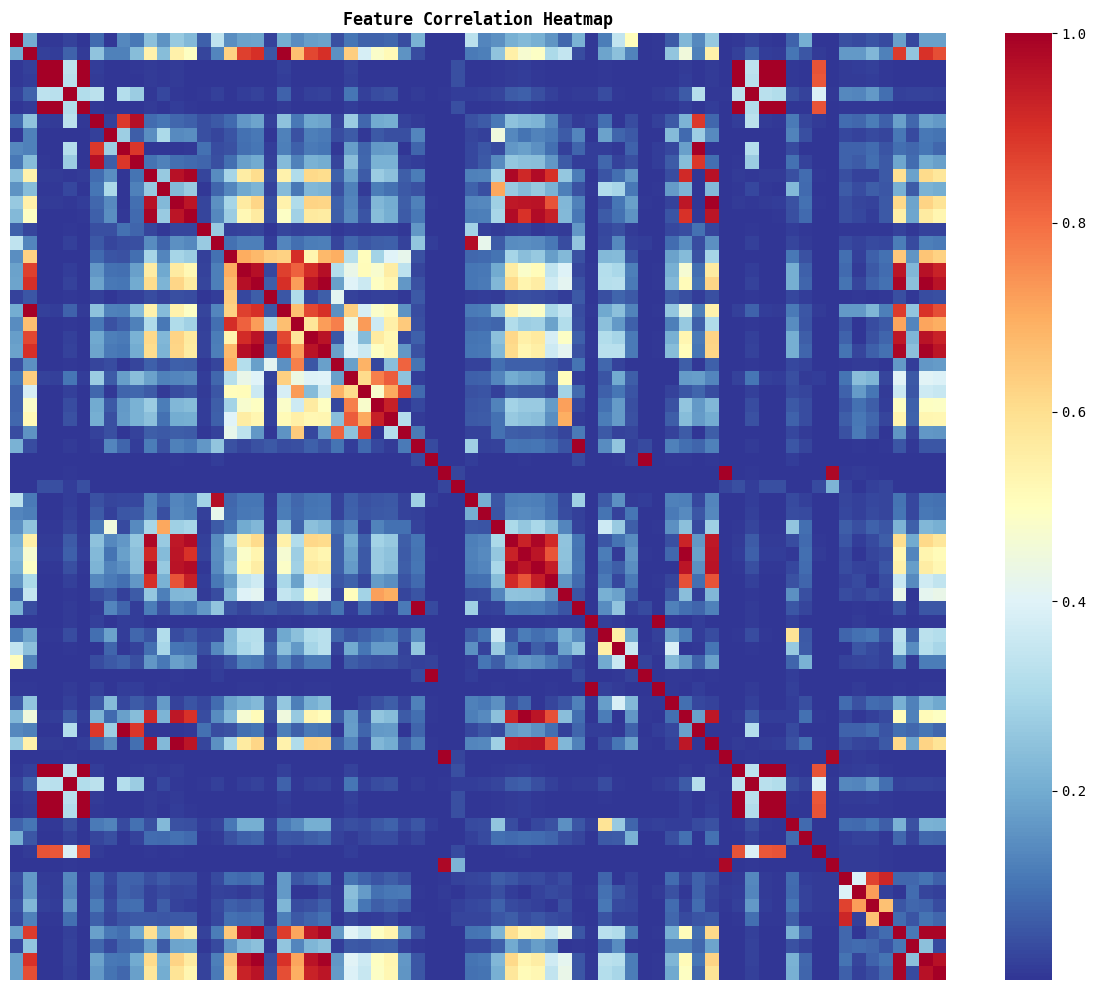

  Saved: correlation_heatmap.png
  Computing mutual info for 42 features...


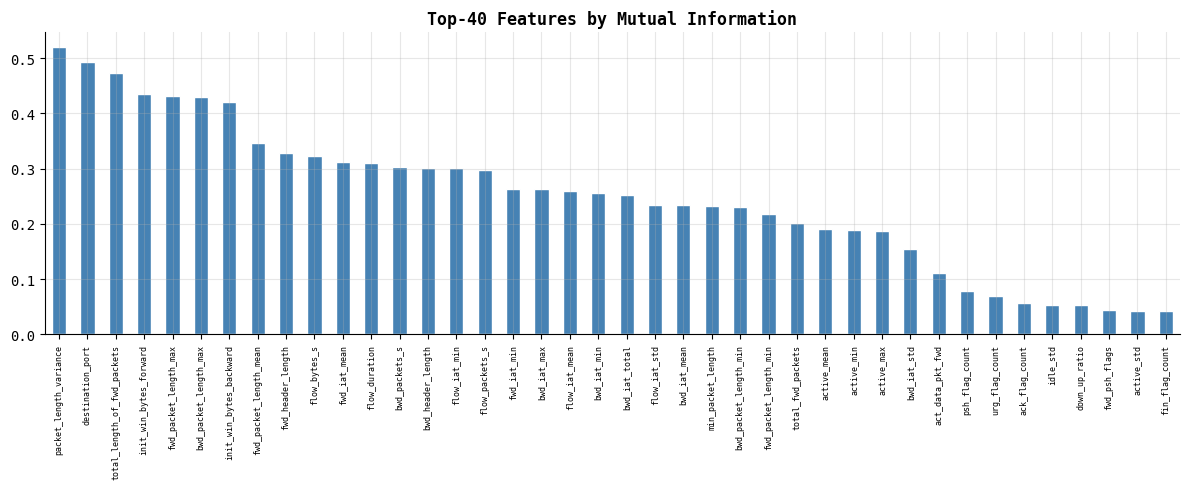

  Saved: mutual_info_importance.png


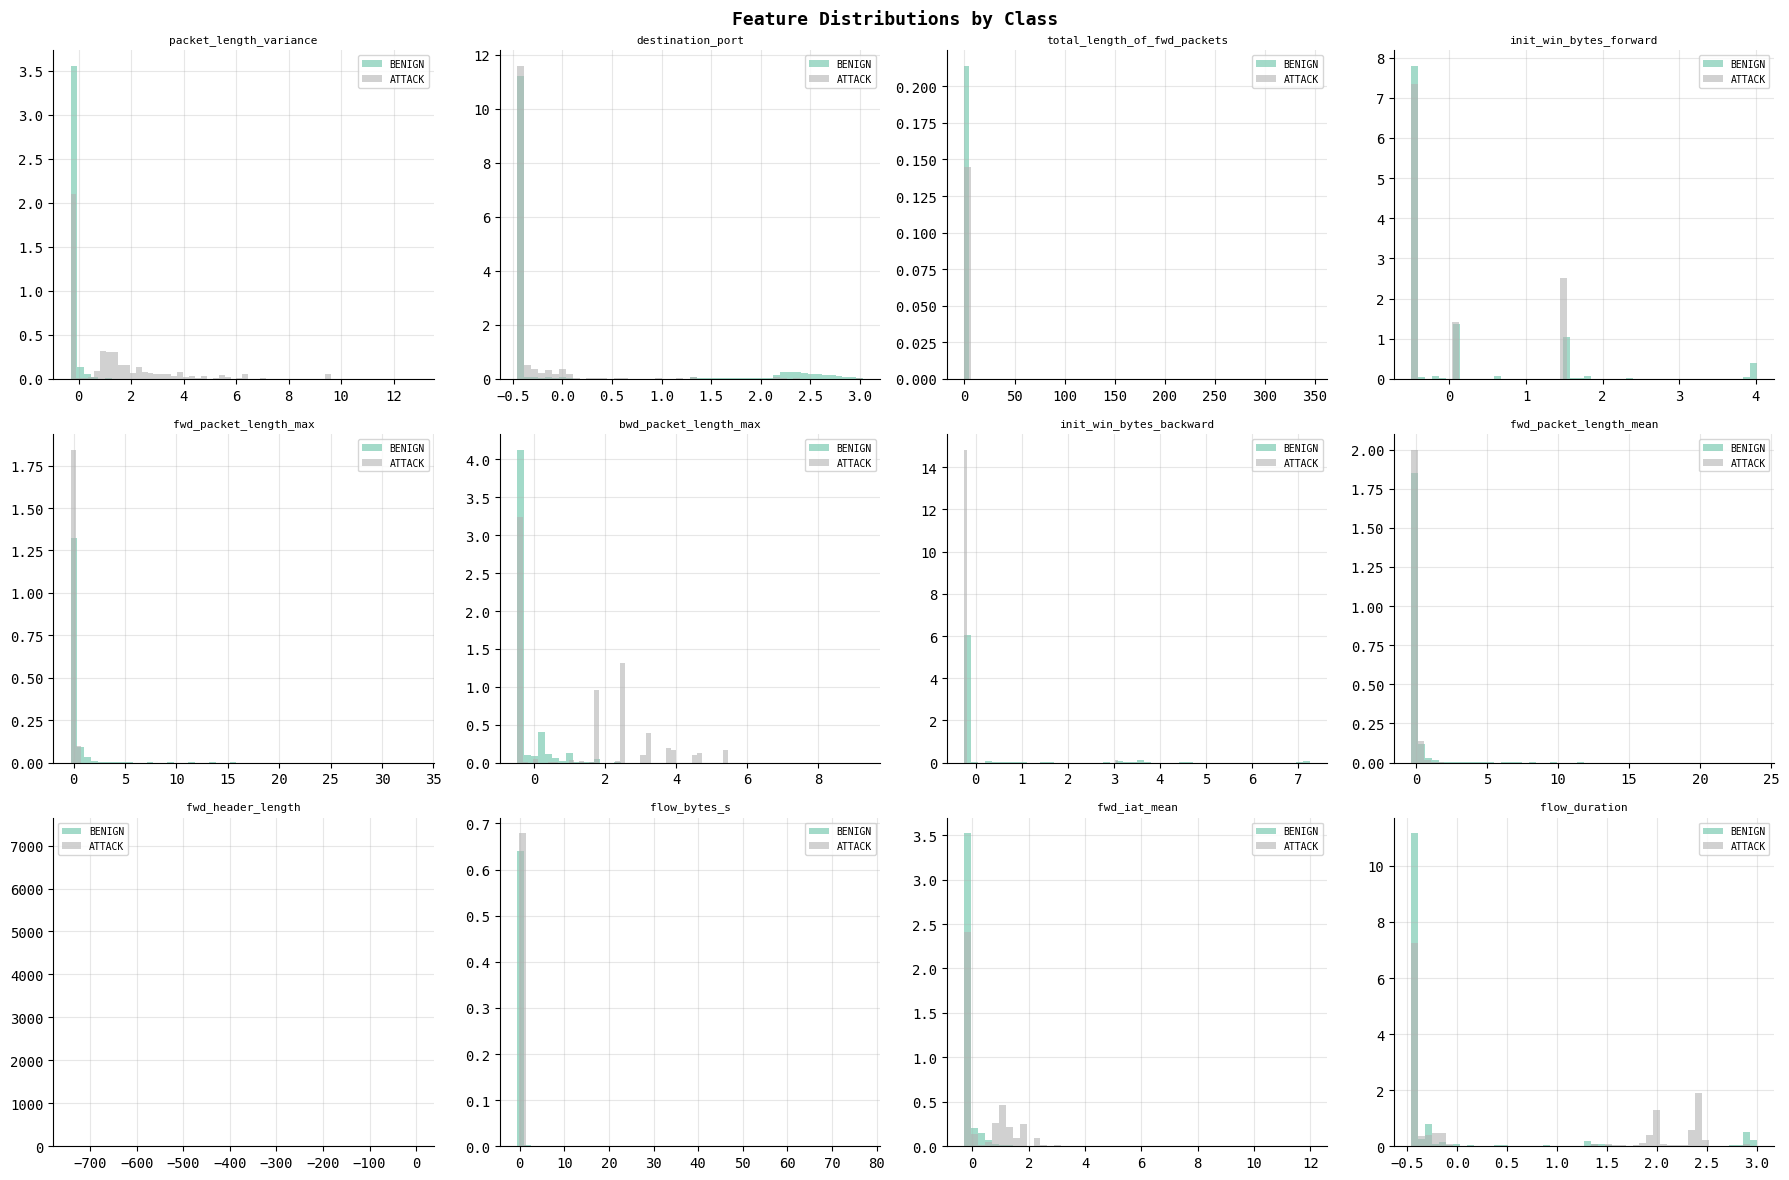

  Saved: feature_distributions.png
  Final features: 40

  ✓ data
Features=40  Classes=2  train=907,018  val=118,065  test=118,066

RUN   Step 2 — build skeletons
  FastKAN built: [40, 128, 64, 2] | params: 121,344
  PolyKAN built: [40, 128, 64, 2] | params: 67,778
  MLP built: [40, 128, 64, 2] | params: 27,330

--- Step 3: Train base models ---
RUN   KAN
  FastKAN built: [40, 128, 64, 2] | params: 121,344
  ep   1/30 | loss 0.0796/0.0572 | acc 0.9685/0.9748 | lr 1.0e-03 | 119.7s/ep | ~58min left
  ep   5/30 | loss 0.0420/0.0452 | acc 0.9840/0.9810 | lr 9.3e-04 | 105.1s/ep | ~47min left
  ep  10/30 | loss 0.0366/0.0462 | acc 0.9860/0.9794 | lr 7.5e-04 | 99.3s/ep | ~35min left
  ep  15/30 | loss 0.0336/0.0391 | acc 0.9869/0.9818 | lr 5.1e-04 | 92.2s/ep | ~25min left
  ep  20/30 | loss 0.0309/0.0364 | acc 0.9879/0.9822 | lr 2.6e-04 | 89.8s/ep | ~16min left
  ep  25/30 | loss 0.0283/0.0359 | acc 0.9888/0.9835 | lr 7.6e-05 | 89.0s/ep | ~8min left
  ep  30/30 | loss 0.0267/0.0347 | acc 0.98

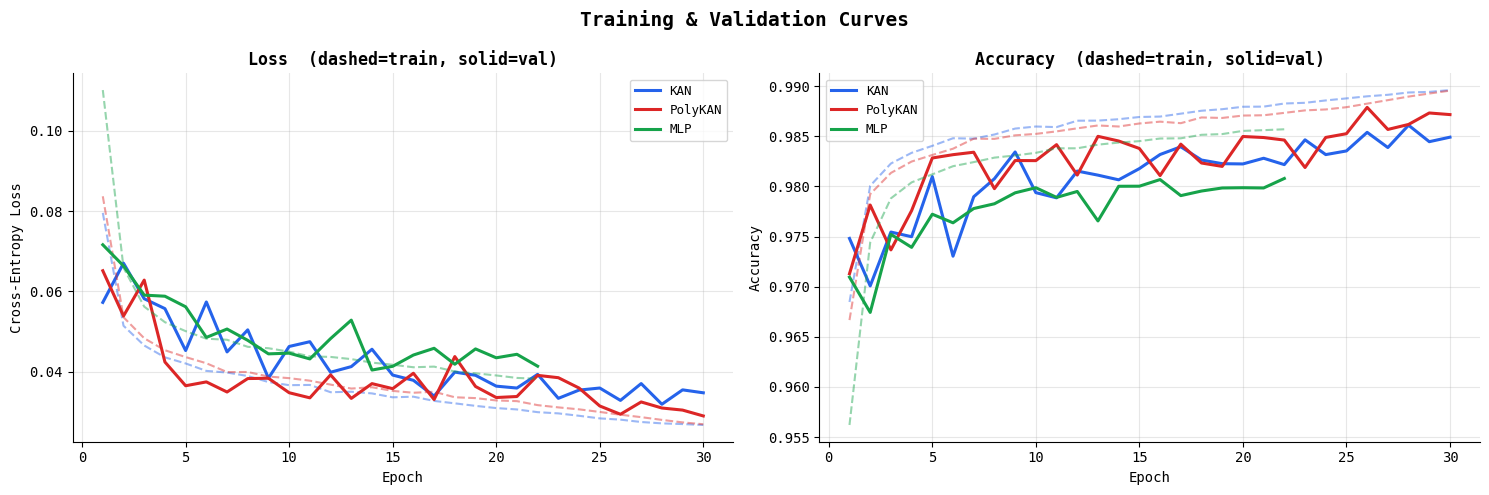

  Saved: training_curves.png


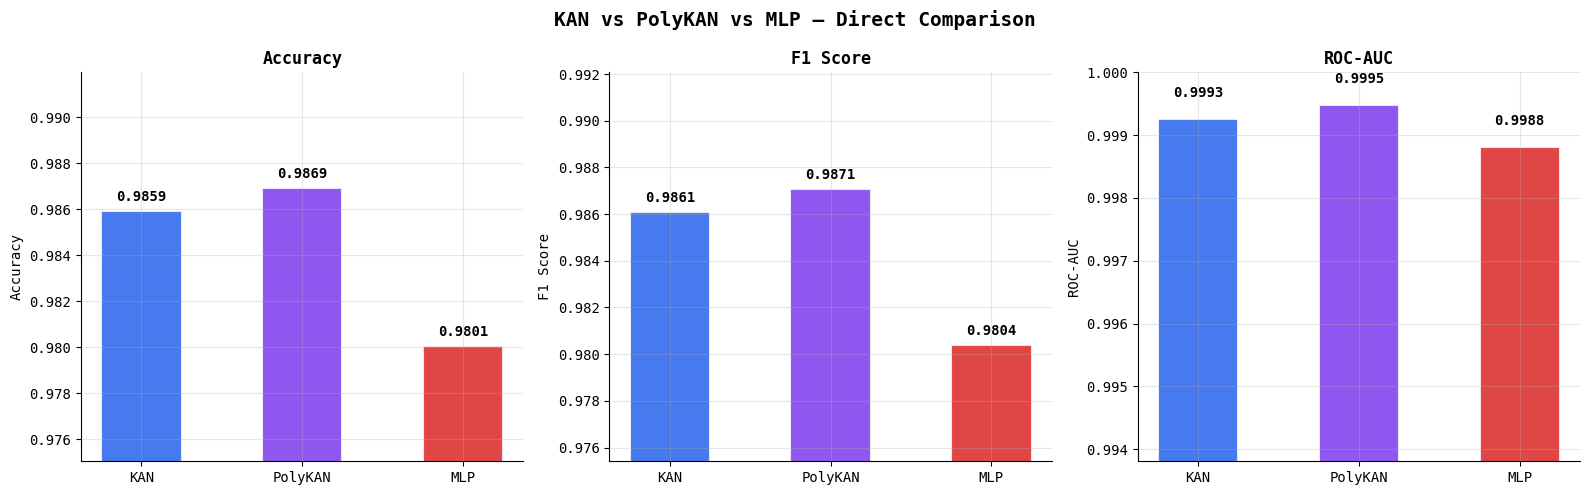

  Saved: kan_vs_mlp_comparison.png


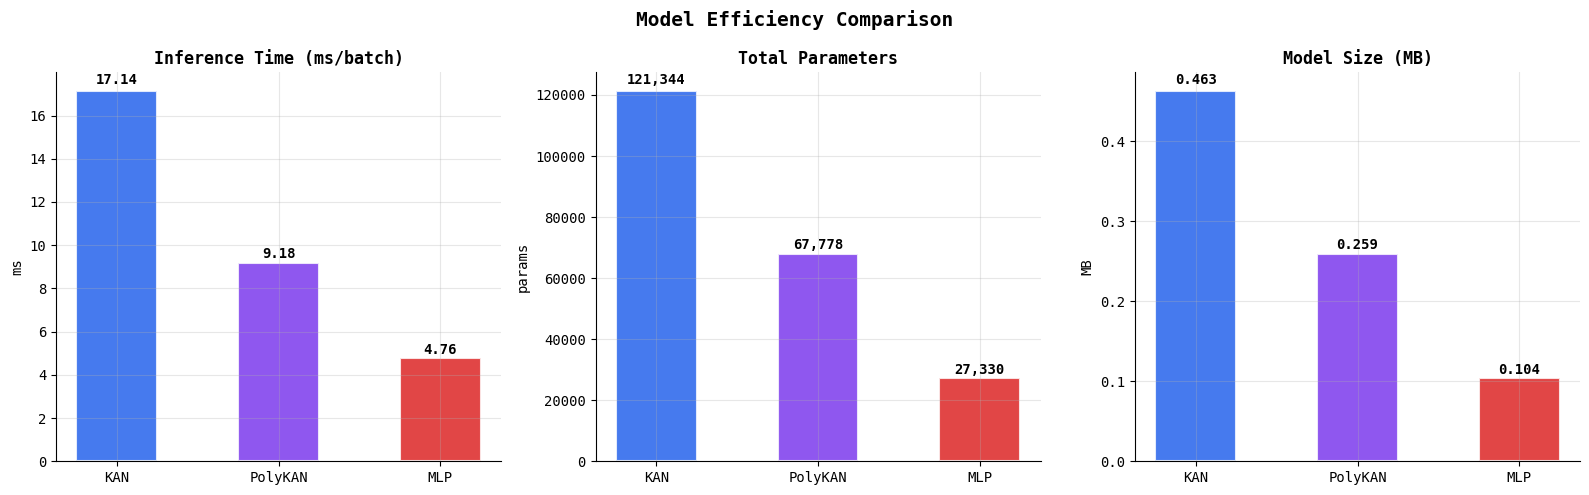

  Saved: efficiency_comparison.png


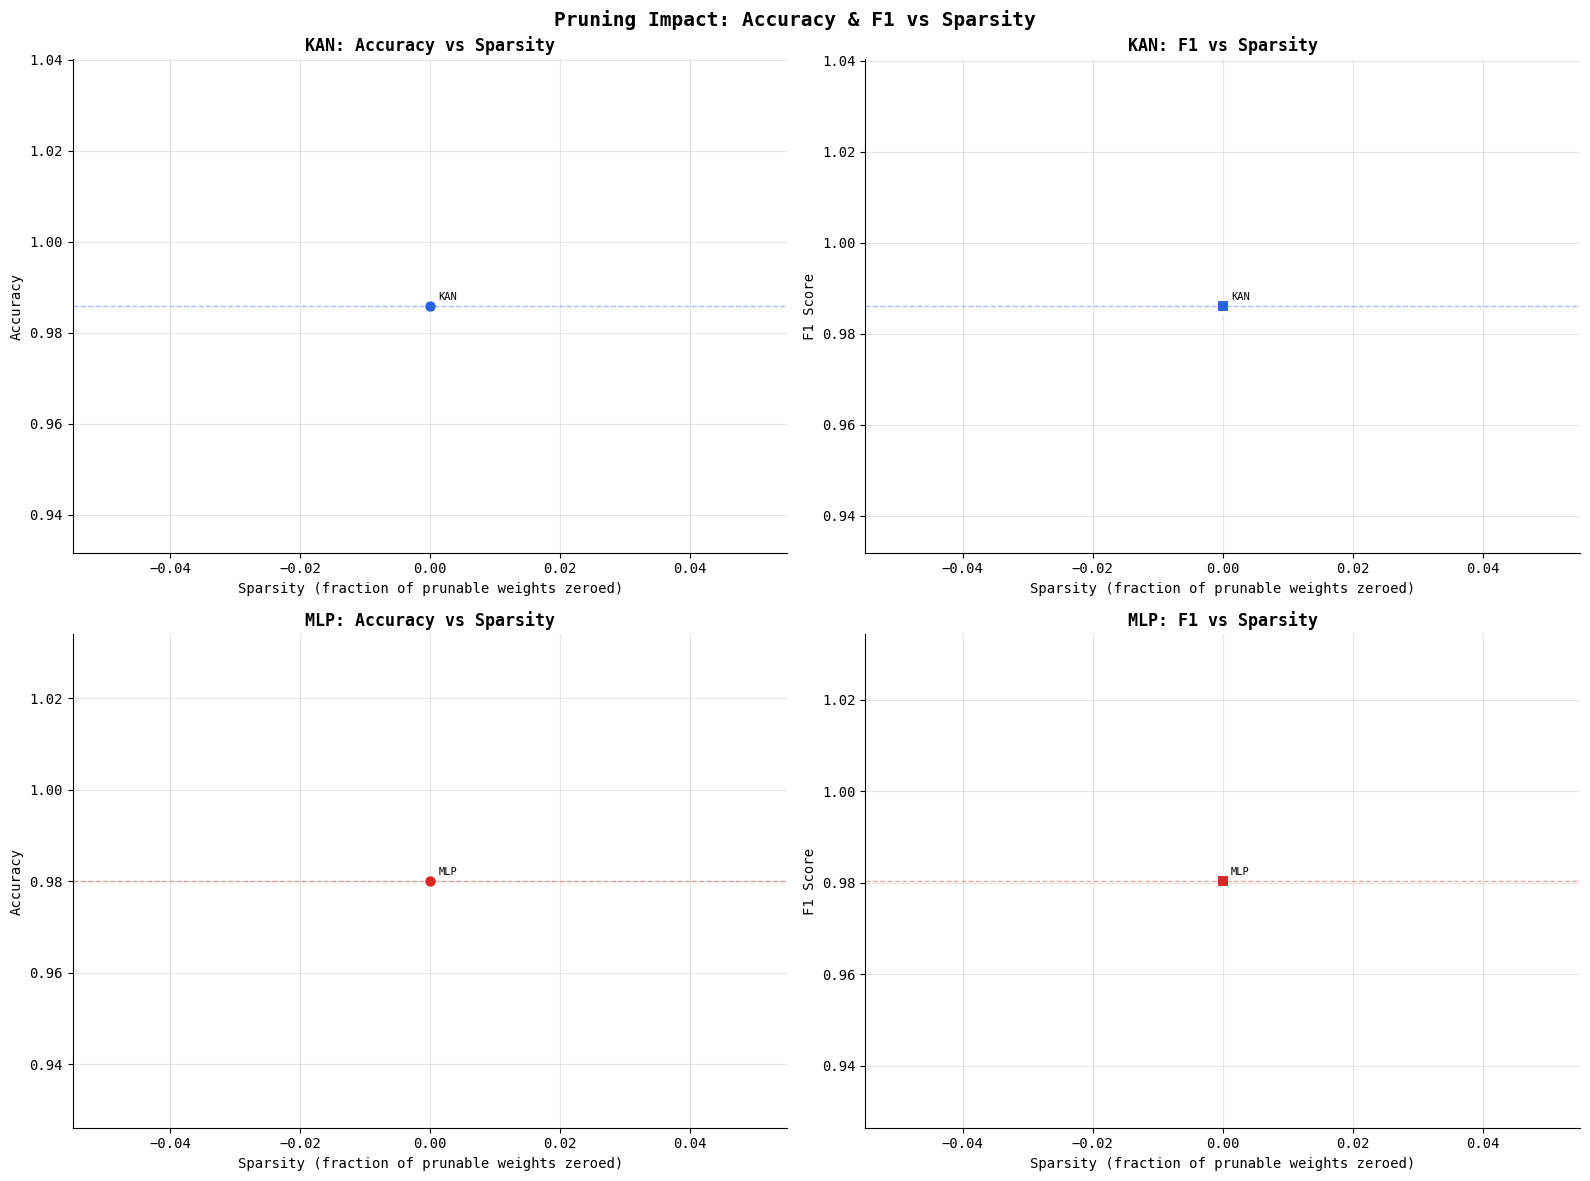

  Saved: pruning_impact.png


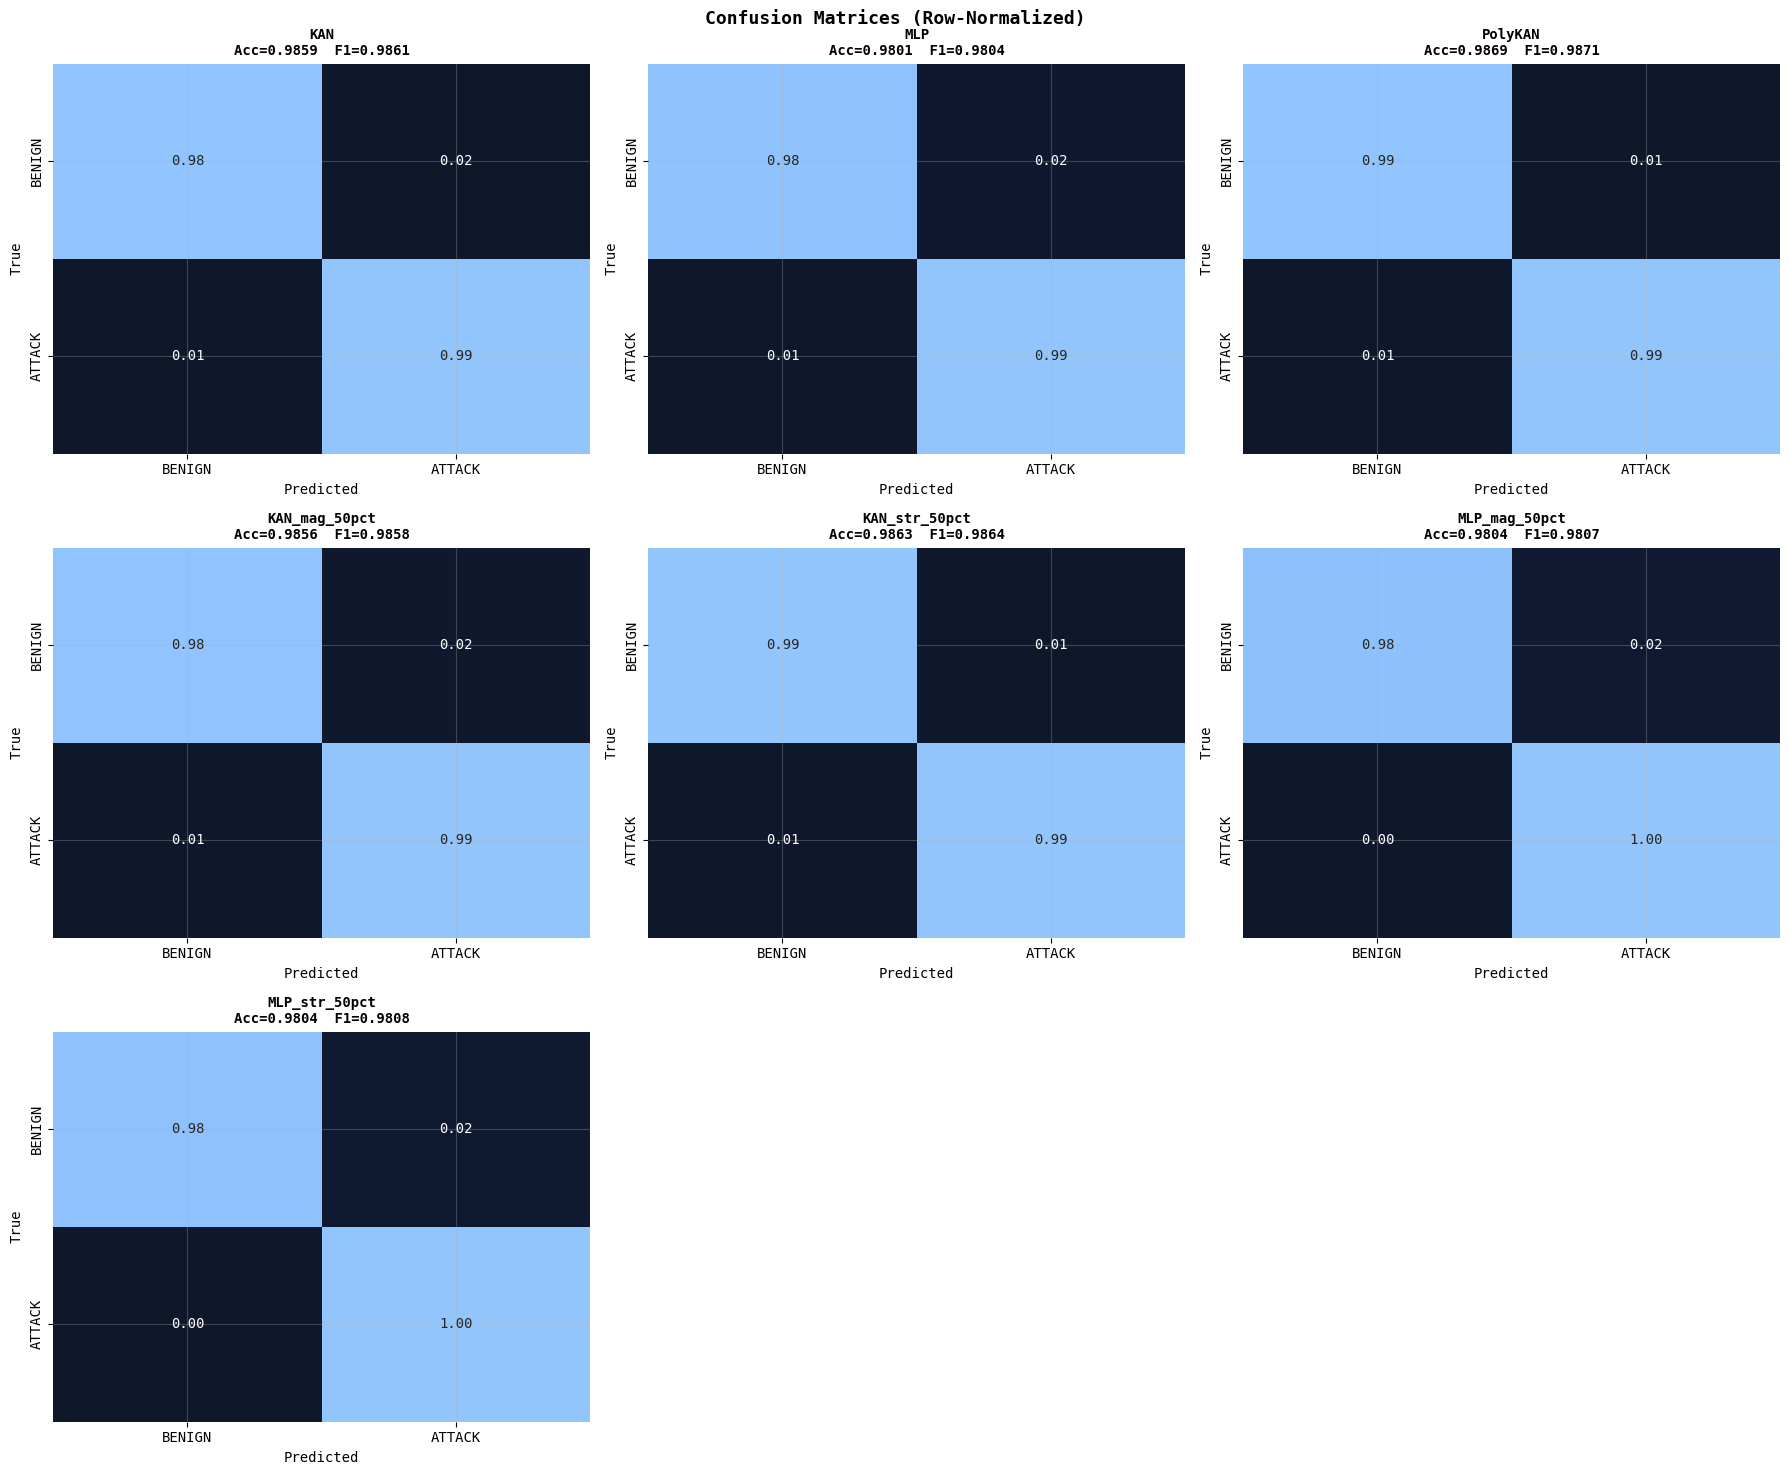

  Saved: confusion_matrices.png


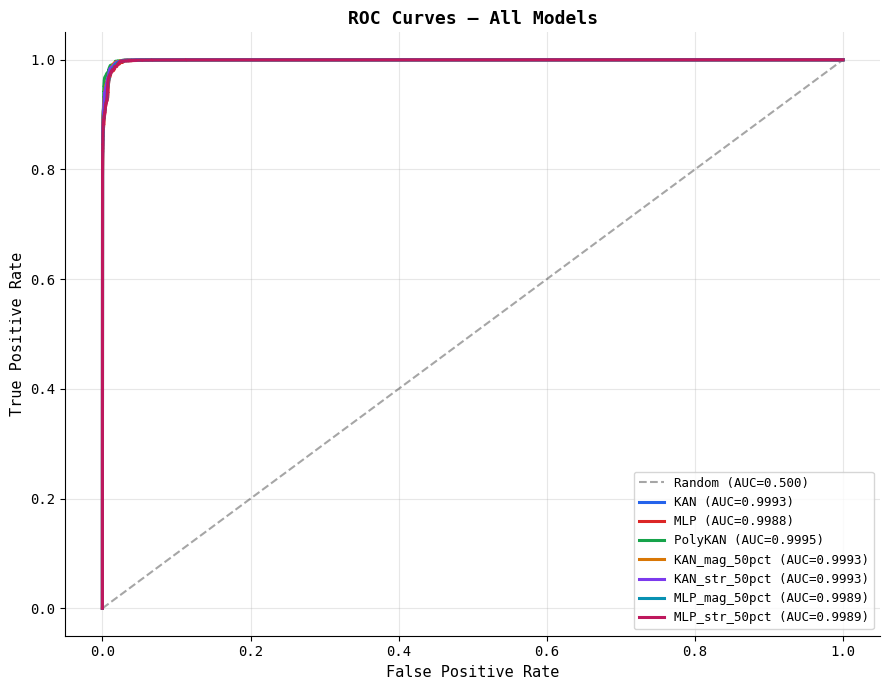

  Saved: roc_curves.png


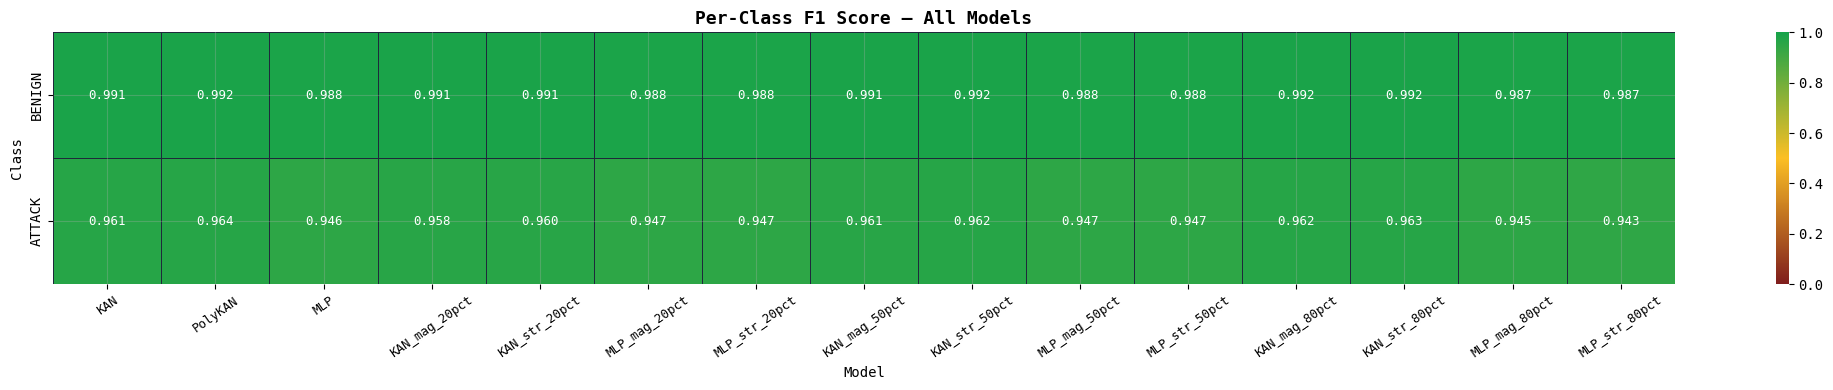

  Saved: per_class_f1.png


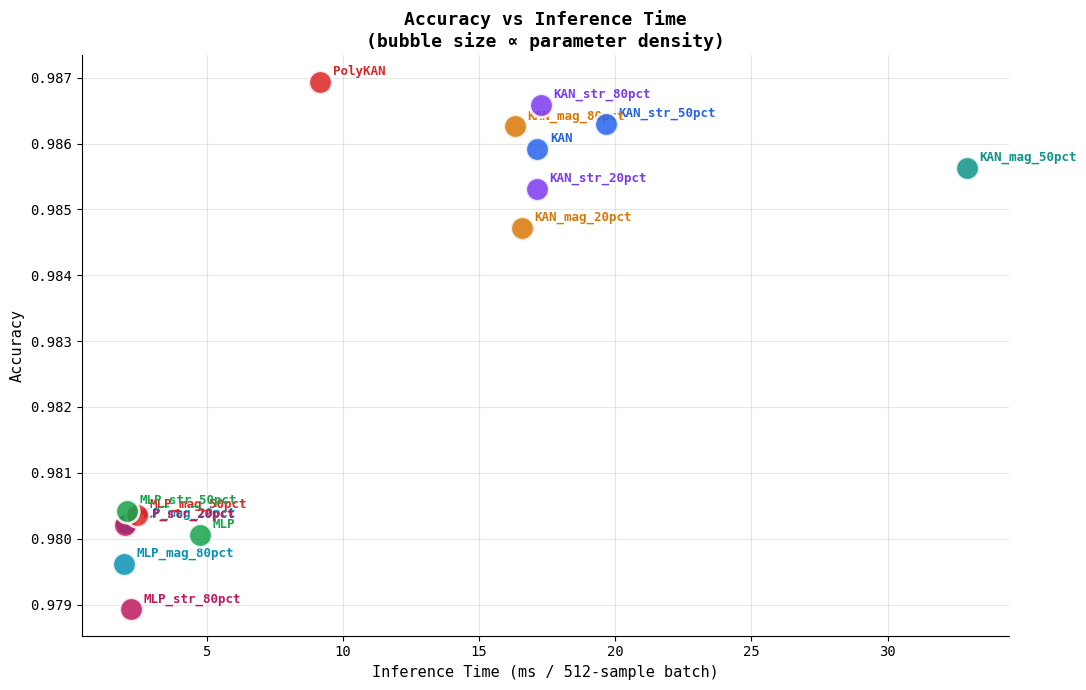

  Saved: accuracy_vs_inference.png


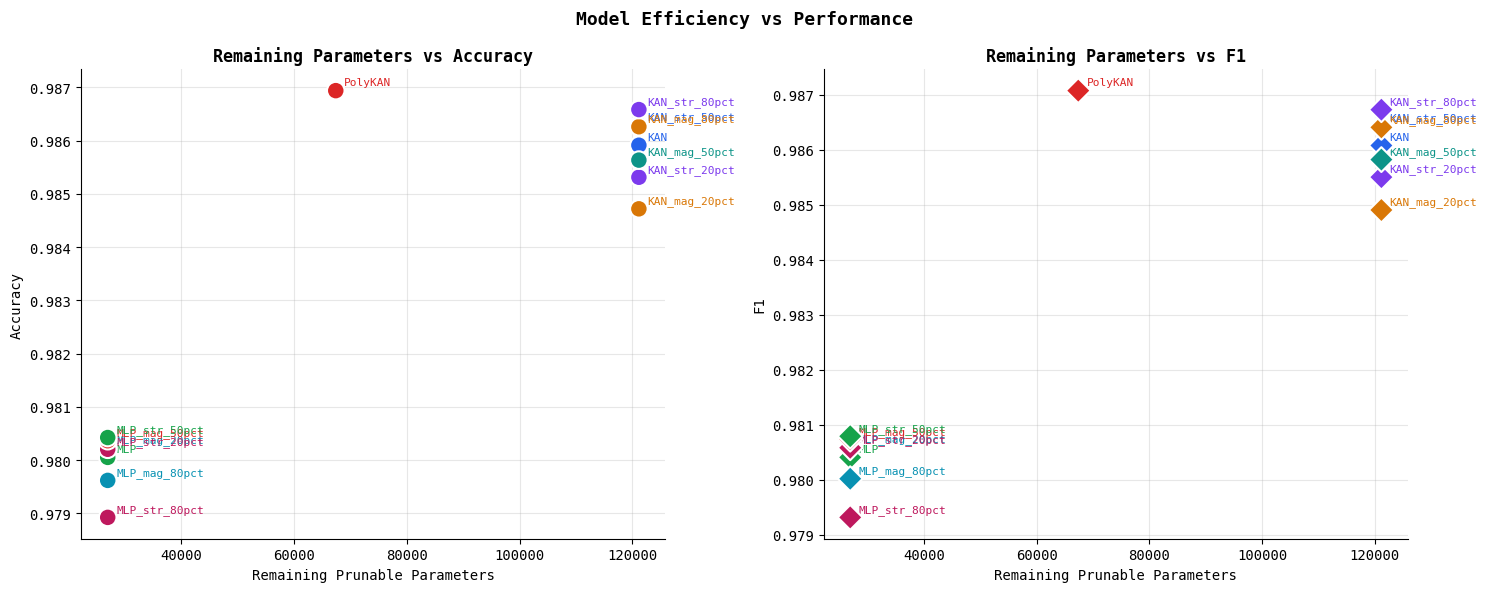

  Saved: params_vs_performance.png
  No KANLayer found.


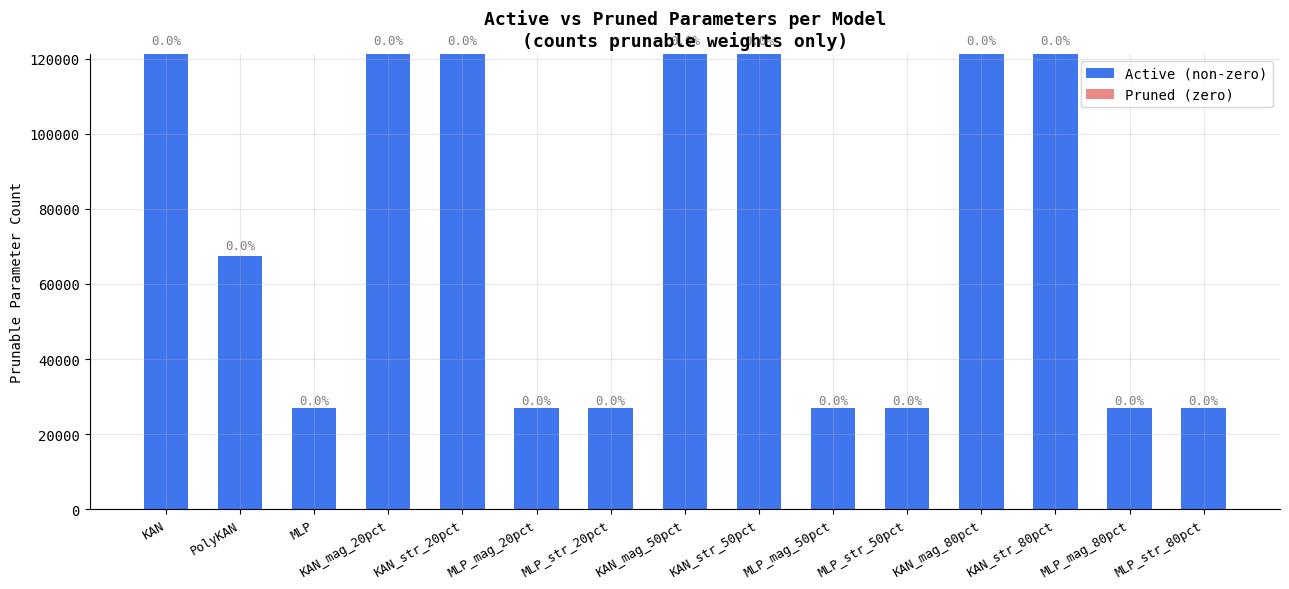

  Saved: network_structure.png


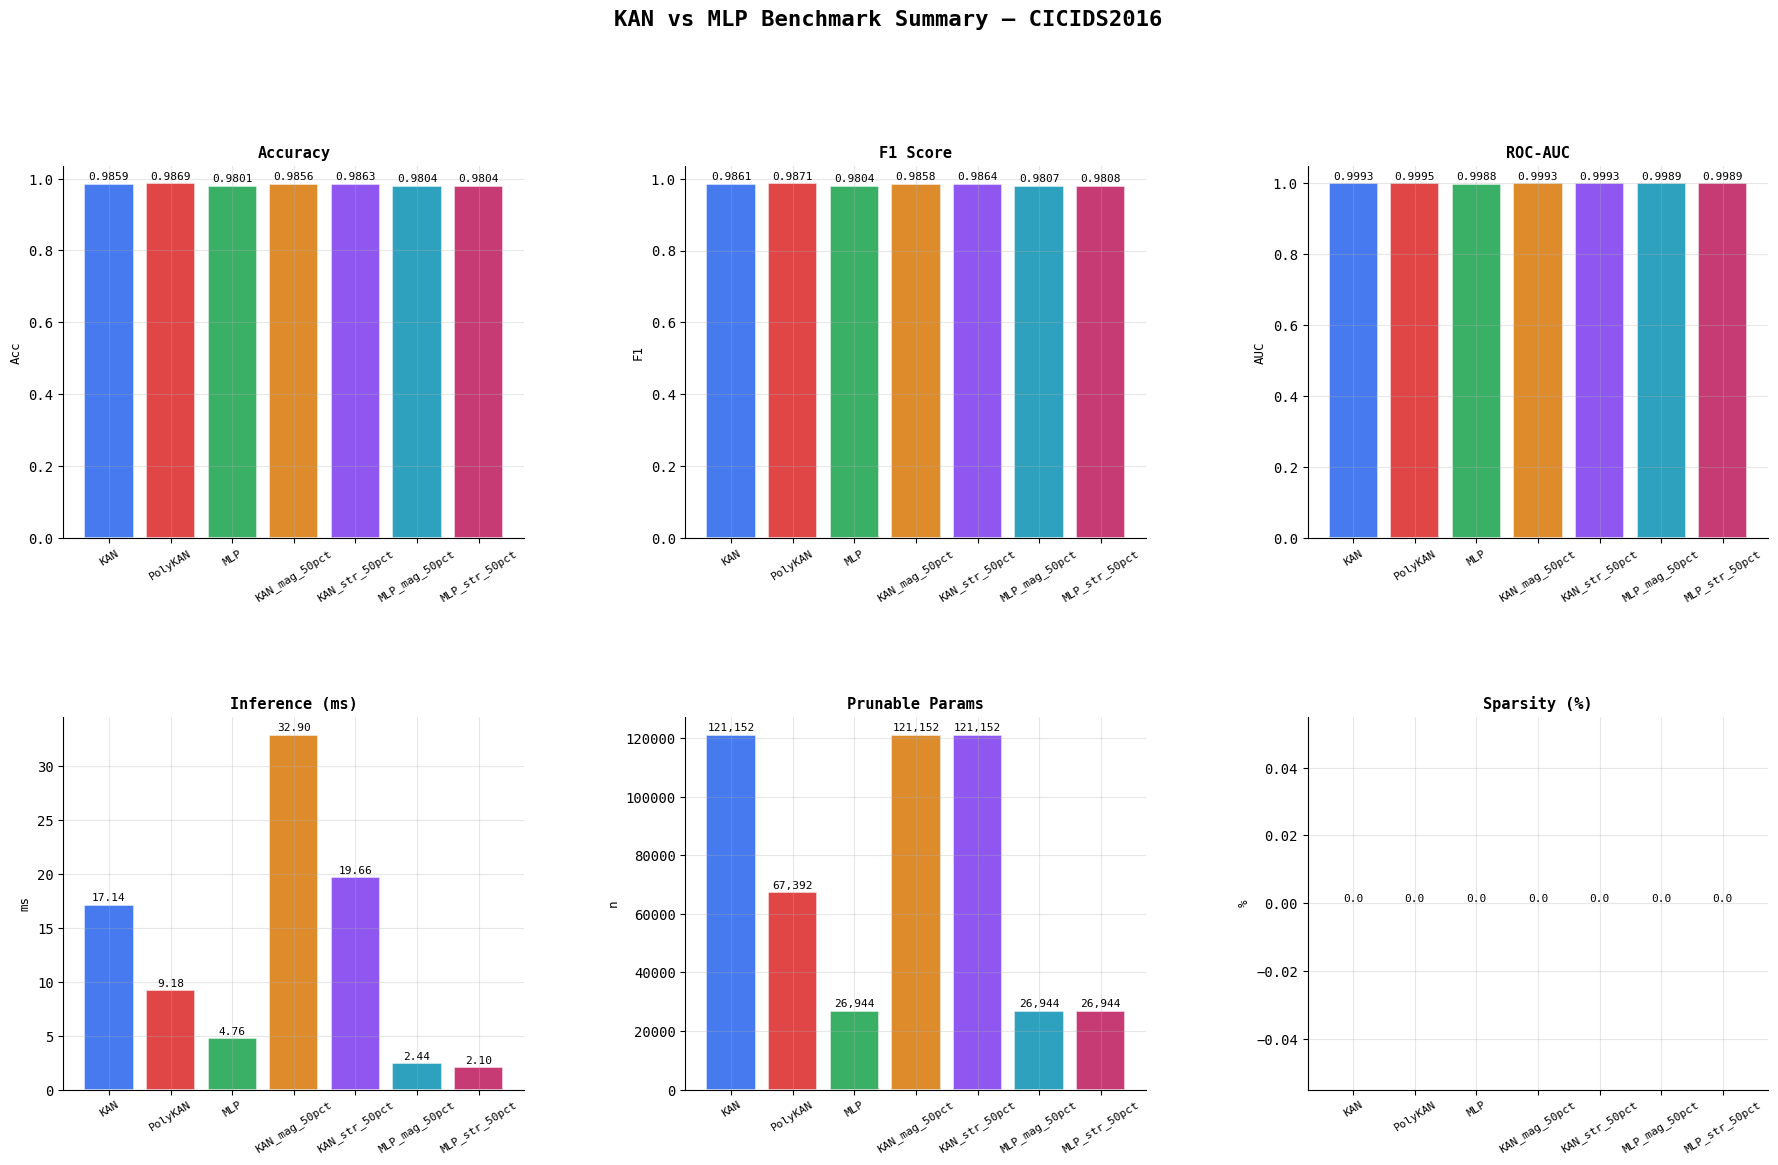

  Saved: summary_dashboard.png
  ✓ viz

--- Step 8: CryptoKAN degree sweep ---
  PolyKAN built: [40, 128, 64, 2] | params: 40,898
RUN   degree=2
  ✓ crypto_2
  d=2: acc=0.9832 f1=0.9834 5.50ms sparsity=0.0%
  PolyKAN built: [40, 128, 64, 2] | params: 54,338
RUN   degree=3
  ✓ crypto_3
  d=3: acc=0.9963 f1=0.9963 7.06ms sparsity=0.0%
  PolyKAN built: [40, 128, 64, 2] | params: 67,778
RUN   degree=4
  ✓ crypto_4
  d=4: acc=0.9841 f1=0.9843 8.81ms sparsity=0.0%
  PolyKAN built: [40, 128, 64, 2] | params: 94,658
RUN   degree=6
  ✓ crypto_6
  d=6: acc=0.9971 f1=0.9971 30.72ms sparsity=0.0%
  PolyKAN built: [40, 128, 64, 2] | params: 121,538
RUN   degree=8
  ✓ crypto_8
  d=8: acc=0.9965 f1=0.9965 17.12ms sparsity=0.0%
  ✓ cryptokan_sweep


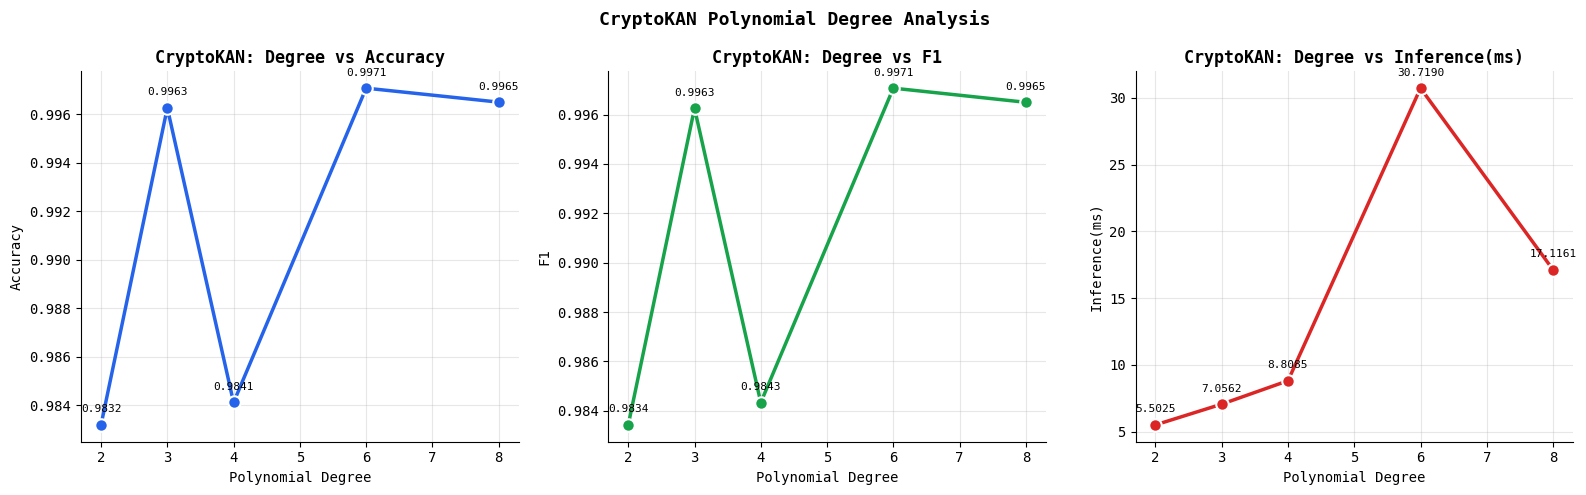


  BENCHMARK COMPARISON
+------------+------------+--------+-------------+----------+-----------+----------------+-------------------+-------------+------------+------------+-------------+------------+
| Model      |   Accuracy |     F1 |   Precision |   Recall |   ROC-AUC | Total Params   | Prunable Params   | Remaining   | Sparsity   |   Train(s) | Infer(ms)   |   Size(MB) |
+============+============+========+=============+==========+===========+================+===================+=============+============+============+=============+============+
| PolyKAN_d2 |     0.9832 | 0.9834 |      0.9842 |   0.9832 |    0.999  | 40,898         | 40,512            | 40,512      | 0.0%       |     1270.8 | 5.50±0.73   |      0.156 |
+------------+------------+--------+-------------+----------+-----------+----------------+-------------------+-------------+------------+------------+-------------+------------+
| PolyKAN_d3 |     0.9963 | 0.9963 |      0.9963 |   0.9963 |    0.9998 | 54,338      

In [ ]:
"""
run_pipeline.py  —  resumable pipeline, full dataset, fast KAN
================================================================
Speed strategy:
  - FastKAN (RBF kernels) instead of B-spline KAN: ~8x faster per epoch
  - sample_frac=0.3  — 30% of full dataset (~840k rows on real CICIDS2016)
    Still large enough for meaningful results, finishes in ~1-2h on CPU
  - batch_size=2048  — larger batches = fewer Python loop iterations
  - epochs=30        — enough for convergence with cosine LR + early stopping
  - finetune_ep=10   — enough recovery after pruning
  - DataLoader num_workers=2 — parallel data loading
  - torch.set_num_threads     — use all CPU cores

Resumable: re-run Cell 12 after any interruption.
"""

import os, sys, json, time, pickle, glob
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, '.')
os.makedirs('./data',        exist_ok=True)
os.makedirs('./checkpoints', exist_ok=True)

# Use all CPU cores
torch.set_num_threads(os.cpu_count() or 4)
print(f'Using {torch.get_num_threads()} CPU threads')

from data_loader         import prepare_data
from feature_engineering import run_feature_engineering
from model_kan           import build_kan
from model_mlp           import build_mlp
from pruning             import (magnitude_prune, structured_prune_mlp,
                                  structured_prune_kan, count_nonzero_params)
from train               import train_model, finetune_pruned
from evaluate            import evaluate_model
from metrics             import (print_comparison_table, print_tradeoff_analysis,
                                  print_per_class_f1)
from visualization       import (plot_training_curves,
                                  plot_kan_vs_mlp,
                                  plot_efficiency_comparison,
                                  plot_pruning_impact,
                                  plot_confusion_matrices,
                                  plot_roc_curves,
                                  plot_per_class_f1,
                                  plot_accuracy_vs_inference,
                                  plot_params_vs_performance,
                                  visualize_kan_functions,
                                  visualize_network_structure,
                                  plot_summary_dashboard)

# ══════════════════════════════════════════════════════════════════════════════
#  CONFIG
# ══════════════════════════════════════════════════════════════════════════════
CFG = dict(
    # ── Data ──────────────────────────────────────────────────────────────────
    data_dir        = './data',
    mode            = 'binary',       # 'binary' or 'multiclass'
    sample_frac     = 0.3,            # 30% of dataset → real results, ~1-2h
                                      # set 1.0 for full run (~6h)
                                      # set 0.1 for quick test (~15min)
    imbalance       = 'smote',
    feature_method  = 'mutual_info',
    top_k           = 40,

    # ── Architecture ──────────────────────────────────────────────────────────
    hidden_sizes    = [128, 64],
    grid_size       = 8,              # RBF centres per feature (FastKAN)
    spline_order    = 3,              # only used if fast=False
    dropout         = 0.1,
    fast_kan        = True,           # True = RBF-KAN (~8x faster than B-spline)
                                      # False = original B-spline KAN (slower, slightly better)

    # ── Training ──────────────────────────────────────────────────────────────
    epochs          = 30,
    batch_size      = 2048,           # larger batch = faster epochs
    lr              = 1e-3,
    weight_decay    = 1e-4,
    patience        = 8,
    finetune_ep     = 10,
    num_workers     = 2,              # parallel data loading

    # ── Pruning ───────────────────────────────────────────────────────────────
    sparsity_levels = [0.2, 0.5, 0.8],

    # ── System ────────────────────────────────────────────────────────────────
    device          = 'cpu',
    seed            = 42,
)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

print('KAN vs MLP on CICIDS2016')
print(f'  sample_frac={CFG["sample_frac"]}  fast_kan={CFG["fast_kan"]}  '
      f'batch={CFG["batch_size"]}  epochs={CFG["epochs"]}')


# ══════════════════════════════════════════════════════════════════════════════
#  CHECKPOINT HELPERS
# ══════════════════════════════════════════════════════════════════════════════
CKPT = './checkpoints'
STATE_FILE = os.path.join(CKPT, 'pipeline_state.json')

def _state():
    return json.load(open(STATE_FILE)) if os.path.exists(STATE_FILE) else {}

def _save(state):
    json.dump(state, open(STATE_FILE, 'w'), indent=2)

def ck(name):
    return os.path.join(CKPT, name)

def done(state, key):
    return state.get(key, False)

def mark(state, key):
    state[key] = True; _save(state)
    print(f'  ✓ {key}')

def save_data(d):
    payload = {k: v for k, v in d.items() if k not in ('label_encoder','scaler')}
    pickle.dump(payload,        open(ck('data.pkl'),   'wb'))
    if d.get('scaler'):         pickle.dump(d['scaler'],        open(ck('scaler.pkl'), 'wb'))
    if d.get('label_encoder'):  pickle.dump(d['label_encoder'], open(ck('le.pkl'),     'wb'))

def load_data():
    d = pickle.load(open(ck('data.pkl'), 'rb'))
    for key, f in [('scaler','scaler.pkl'),('label_encoder','le.pkl')]:
        if os.path.exists(ck(f)): d[key] = pickle.load(open(ck(f),'rb'))
    return d

def svm(model, name):   torch.save(model.state_dict(), ck(f'{name}.pt'))
def lvm(model, name):   model.load_state_dict(torch.load(ck(f'{name}.pt'), map_location='cpu')); return model
def svx(obj,   name):   pickle.dump(obj,  open(ck(f'{name}.pkl'),'wb'))
def ldx(name):          return pickle.load(open(ck(f'{name}.pkl'),'rb'))
def svt(name,  t):      json.dump({'t':t}, open(ck(f'{name}_t.json'),'w'))
def ldt(name):
    p = ck(f'{name}_t.json')
    return json.load(open(p))['t'] if os.path.exists(p) else 0.0


# ══════════════════════════════════════════════════════════════════════════════
#  PIPELINE
# ══════════════════════════════════════════════════════════════════════════════
state = _state()
done_list = [k for k, v in state.items() if v]
print(f'\nDone: {done_list if done_list else "none — fresh start"}\n')


# ── Step 1: Data ───────────────────────────────────────────────────────────────
if done(state, 'data'):
    print('SKIP  Step 1 — data')
    data = load_data()
else:
    print('RUN   Step 1 — data')
    data = prepare_data(
        data_dir=CFG['data_dir'], mode=CFG['mode'],
        sample_frac=CFG['sample_frac'], imbalance_strategy=CFG['imbalance'],
        random_state=CFG['seed'])
    data = run_feature_engineering(
        data, method=CFG['feature_method'], top_k=CFG['top_k'])
    save_data(data); mark(state, 'data')

N, C = data['n_features'], data['n_classes']
CLASS_NAMES = ['BENIGN', 'ATTACK'] if C == 2 else None
print(f'Features={N}  Classes={C}  '
      f'train={len(data["X_train"]):,}  val={len(data["X_val"]):,}  test={len(data["X_test"]):,}')


# ── Step 2: Build skeletons ────────────────────────────────────────────────────
print('\nRUN   Step 2 — build skeletons')

def _build_kan():
    return build_kan(N, C, CFG['hidden_sizes'], CFG['grid_size'],
                     CFG['spline_order'], CFG['dropout'],
                     use_poly=False, fast=CFG['fast_kan'])

def _build_poly():
    return build_kan(N, C, CFG['hidden_sizes'], dropout=CFG['dropout'],
                     use_poly=True, poly_degree=4)

def _build_mlp():
    return build_mlp(N, C, CFG['hidden_sizes'], CFG['dropout'])

kan_model      = _build_kan()
poly_kan_model = _build_poly()
mlp_model      = _build_mlp()


# ── Step 3: Train base models ──────────────────────────────────────────────────
print('\n--- Step 3: Train base models ---')
histories, train_times = {}, {}

for name, builder in [('KAN',_build_kan),('PolyKAN',_build_poly),('MLP',_build_mlp)]:
    key = f'train_{name}'
    if done(state, key):
        print(f'SKIP  {name}')
        model             = lvm(builder(), name)
        histories[name]   = ldx(f'{name}_hist')
        train_times[name] = ldt(name)
    else:
        print(f'RUN   {name}')
        model = builder()
        res = train_model(
            model, data,
            epochs       = CFG['epochs'],
            batch_size   = CFG['batch_size'],
            lr           = CFG['lr'],
            weight_decay = CFG['weight_decay'],
            patience     = CFG['patience'],
            device_str   = CFG['device'],
            num_workers  = CFG['num_workers'],
        )
        model             = res['model']
        histories[name]   = res['history']
        train_times[name] = res['train_time']
        svm(model, name); svx(res['history'], f'{name}_hist'); svt(name, res['train_time'])
        mark(state, key)

    if name == 'KAN':       kan_model      = model
    elif name == 'PolyKAN': poly_kan_model = model
    else:                   mlp_model      = model


# ── Step 4: Pruning ────────────────────────────────────────────────────────────
print('\n--- Step 4: Pruning ---')
pruned_models = {}

prune_jobs = []
for sp in CFG['sparsity_levels']:
    lbl = f'{int(sp*100)}pct'
    prune_jobs += [
        (f'KAN_mag_{lbl}', magnitude_prune,      sp, kan_model, 'KAN', _build_kan),
        (f'KAN_str_{lbl}', structured_prune_kan, sp, kan_model, 'KAN', _build_kan),
        (f'MLP_mag_{lbl}', magnitude_prune,      sp, mlp_model, 'MLP', _build_mlp),
        (f'MLP_str_{lbl}', structured_prune_mlp, sp, mlp_model, 'MLP', _build_mlp),
    ]

for name, prune_fn, sp, base, arch, builder in prune_jobs:
    key = f'prune_{name}'
    if done(state, key):
        print(f'SKIP  {name}')
        sk                = lvm(builder(), name)
        histories[name]   = ldx(f'{name}_hist')
        train_times[name] = ldt(name)
    else:
        print(f'RUN   {name}')
        pm  = prune_fn(base, sparsity=sp)
        ft  = finetune_pruned(pm, data, epochs=CFG['finetune_ep'],
                              batch_size=CFG['batch_size'],
                              device_str=CFG['device'],
                              num_workers=CFG['num_workers'])
        sk                = ft['model']
        histories[name]   = ft['history']
        train_times[name] = ft['train_time']
        svm(sk, name); svx(ft['history'], f'{name}_hist'); svt(name, ft['train_time'])
        mark(state, key)
    pruned_models[name] = sk


# ── Step 5: Evaluate ───────────────────────────────────────────────────────────
print('\n--- Step 5: Evaluate ---')
all_results  = {}
eval_targets = (
    [('KAN',kan_model),('PolyKAN',poly_kan_model),('MLP',mlp_model)]
    + list(pruned_models.items())
)

for name, model in eval_targets:
    key = f'eval_{name}'
    if done(state, key):
        print(f'SKIP  {name}')
        r = ldx(f'{name}_result')
    else:
        print(f'RUN   {name}')
        r               = evaluate_model(model, data, split='test',
                                         device_str=CFG['device'])
        r['train_time'] = train_times.get(name, 0)
        svx(r, f'{name}_result'); mark(state, key)
    all_results[name] = r


# ── Step 6: Tables ─────────────────────────────────────────────────────────────
print('\n--- Step 6: Results ---')
df = print_comparison_table(all_results)
print_tradeoff_analysis(all_results)
print_per_class_f1(all_results, class_names=CLASS_NAMES)
df.to_csv('benchmark_results.csv', index=False)
print('Saved: benchmark_results.csv')


# ── Step 7: Visualizations ─────────────────────────────────────────────────────
if done(state, 'viz'):
    print('\nSKIP  Step 7 — visualizations')
else:
    print('\n--- Step 7: Visualizations ---')

    plot_training_curves({k: histories[k] for k in ('KAN','PolyKAN','MLP')})
    plot_kan_vs_mlp(all_results)
    plot_efficiency_comparison(all_results)
    plot_pruning_impact(all_results)

    sp_mid = f'{int(CFG["sparsity_levels"][len(CFG["sparsity_levels"])//2]*100)}pct'
    cm_keys = ['KAN','MLP','PolyKAN',
               f'KAN_mag_{sp_mid}',f'KAN_str_{sp_mid}',
               f'MLP_mag_{sp_mid}',f'MLP_str_{sp_mid}']
    plot_confusion_matrices(
        {k: all_results[k] for k in cm_keys if k in all_results},
        class_names=CLASS_NAMES)
    plot_roc_curves({k: all_results[k] for k in cm_keys if k in all_results})
    plot_per_class_f1(all_results, class_names=CLASS_NAMES)
    plot_accuracy_vs_inference(all_results)
    plot_params_vs_performance(all_results)
    visualize_kan_functions(kan_model, data['feature_names'])
    visualize_network_structure(all_results)

    dash_keys = ['KAN','PolyKAN','MLP',
                 f'KAN_mag_{sp_mid}',f'KAN_str_{sp_mid}',
                 f'MLP_mag_{sp_mid}',f'MLP_str_{sp_mid}']
    plot_summary_dashboard({k: all_results[k] for k in dash_keys if k in all_results})
    mark(state, 'viz')


# ── Step 8: CryptoKAN degree sweep ────────────────────────────────────────────
print('\n--- Step 8: CryptoKAN degree sweep ---')
poly_res = {}
for deg in [2, 3, 4, 6, 8]:
    key  = f'PolyKAN_d{deg}'
    skey = f'crypto_{deg}'
    pm   = build_kan(N, C, CFG['hidden_sizes'], dropout=CFG['dropout'],
                     use_poly=True, poly_degree=deg)
    if done(state, skey):
        print(f'SKIP  degree={deg}')
        ev = ldx(f'{key}_result')
    else:
        print(f'RUN   degree={deg}')
        tr = train_model(pm, data, epochs=CFG['epochs'],
                         batch_size=CFG['batch_size'], lr=CFG['lr'],
                         patience=CFG['patience'], device_str=CFG['device'],
                         num_workers=CFG['num_workers'], verbose=False)
        ev               = evaluate_model(tr['model'], data, split='test',
                                          device_str=CFG['device'], verbose=False)
        ev['train_time'] = tr['train_time']
        svm(tr['model'], key); svx(ev, f'{key}_result'); mark(state, skey)
    poly_res[key] = ev
    print(f'  d={deg}: acc={ev["accuracy"]:.4f} f1={ev["f1"]:.4f} '
          f'{ev["inference_ms"]:.2f}ms sparsity={ev["sparsity"]:.1%}')

if not done(state, 'cryptokan_sweep'):
    mark(state, 'cryptokan_sweep')

degrees = [int(k.split('d')[1]) for k in poly_res]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, ylabel, color in zip(axes,
        ['accuracy','f1','inference_ms'],
        ['Accuracy','F1','Inference(ms)'],
        ['#2563EB','#16A34A','#DC2626']):
    vals = [poly_res[f'PolyKAN_d{d}'][metric] for d in degrees]
    ax.plot(degrees, vals, 'o-', color=color, lw=2.5, ms=9,
            markeredgecolor='white', markeredgewidth=1.5)
    for d, v in zip(degrees, vals):
        ax.annotate(f'{v:.4f}', (d, v), textcoords='offset points',
                    xytext=(0, 9), ha='center', fontsize=8)
    ax.set_xlabel('Polynomial Degree')
    ax.set_ylabel(ylabel)
    ax.set_title(f'CryptoKAN: Degree vs {ylabel}', fontweight='bold')
plt.suptitle('CryptoKAN Polynomial Degree Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cryptokan_degree_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print_comparison_table(poly_res)

print('\n' + '='*60)
print('PIPELINE COMPLETE')
print('='*60)
print('Files:', sorted(glob.glob('*.png')) + sorted(glob.glob('*.csv')))
